<div style="background:linear-gradient(135deg,#07090f 0%,#0d1528 100%);padding:36px 44px;border-radius:14px;border-left:6px solid #c084fc;font-family:'Courier New',monospace;margin-bottom:8px">
<h1 style="color:#c084fc;margin:0 0 8px;font-size:2.2em;letter-spacing:2px">⚡ BESS DISPATCH OPTIMIZATION FOR ARBITRAGE IN THE NEM</h1>
<h3 style="color:#8b9dc3;margin:0 0 4px;font-weight:normal">Australian NEM — Price Forecasting → Battery Storage Optimal Dispatch</h3>
<hr style="border:none;border-top:1px solid #263050;margin:18px 0">
<table style="color:#e0e0e0;font-size:0.9em;border-collapse:collapse">
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Market</b></td><td>Australian National Electricity Market (NEM) — SA1 | VIC1 | NSW1 | QLD1 | TAS1</td></tr>
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Framework</b></td><td>Master ML/DL — 12 Steps across 5 Phases</td></tr>
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Data</b></td><td>AEMO TRADINGPRICE — 30-min regional spot prices via NEMOSIS (2 years history)</td></tr>
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Forecast</b></td><td>XGBoost + LightGBM Ensemble · Seasonal Anchor method · Raw price target · Negative price aware</td></tr>
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Dispatch</b></td><td>LP/MILP (CVXPY + GLPK_MI) · Multi-cycle · Negative-price priority charging</td></tr>
<tr><td style="padding:4px 20px 4px 0;color:#c084fc"><b>Outputs</b></td><td>Monthly dashboard · SoC trajectory · Daily detail plot · Revenue analysis · KPI scorecard</td></tr>
</table>
</div>


---
## 🎯 INTERACTIVE — Set Your Target Month & Year

**Edit the values below → `Kernel → Restart & Run All`**

In [30]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║            USER CONFIGURATION — EDIT HERE                       ║
# ╚══════════════════════════════════════════════════════════════════╝

TARGET_YEAR   = 2026    # ← Year to forecast  (e.g. 2024, 2025)
TARGET_MONTH  = 4       # ← Month 1–12        (1=Jan, 6=Jun, 12=Dec)
NEM_REGION    = 'VIC1'   # ← SA1 | VIC1 | NSW1 | QLD1 | TAS1
HISTORY_YEARS = 3       # ← Years of training history

# ── BESS Physical Specs (modify for your asset) ──────────────────────
BESS_POWER_MW      = 100.0   # Rated power [MW]
BESS_CAPACITY_MWH  = 200.0   # Nominal energy capacity [MWh]
BESS_ETA_CHARGE    = 0.950   # Charging efficiency  η_c
BESS_ETA_DISCHARGE = 0.950   # Discharging efficiency η_d
BESS_SOC_MIN       = 0.10    # Min SoC (protects battery floor)
BESS_SOC_MAX       = 0.90    # Max SoC (protects battery ceiling)
BESS_SOC_INIT      = 0.50    # Initial SoC for each day
BESS_CAPEX_KWH     = 220.0   # Capital cost [$/kWh installed]
BESS_CYCLES_LIFE   = 4000.0  # LFP cycle life at 80% DoD

# ── Model Options ─────────────────────────────────────────────────────
RUN_HPO  = False   # True = Optuna hyperparameter search (~10 min extra)
N_TRIALS = 60      # HPO trials (if RUN_HPO=True)
PLOT_DAY = None    # Specific day for detail plot: 'YYYY-MM-DD' or None (auto)

# ── Validation ────────────────────────────────────────────────────────
import calendar as _cal
print(f"  Target:    {_cal.month_name[TARGET_MONTH]} {TARGET_YEAR}  |  Region: {NEM_REGION}")
print(f"  BESS:      {BESS_POWER_MW:.0f} MW / {BESS_CAPACITY_MWH:.0f} MWh  (E/P = {BESS_CAPACITY_MWH/BESS_POWER_MW:.1f} h)")
print(f"  RTE:       {BESS_ETA_CHARGE*BESS_ETA_DISCHARGE*100:.2f}%")
print(f"  HPO:       {RUN_HPO}  ({N_TRIALS} trials if enabled)")

  Target:    April 2026  |  Region: VIC1
  BESS:      100 MW / 200 MWh  (E/P = 2.0 h)
  RTE:       90.25%
  HPO:       False  (60 trials if enabled)


---
## ⚙️ Setup — Imports, Directories & Dependency Check

In [31]:
# ── Standard Library ─────────────────────────────────────────────────
import os, sys, json, hashlib, warnings, pickle, time, calendar
from pathlib import Path
from datetime import date, timedelta, datetime
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

warnings.filterwarnings('ignore')
os.makedirs('data',    exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('models',  exist_ok=True)

# ── Scientific Stack ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats as sp_stats
np.random.seed(42)

# ── Scikit-Learn ──────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# ── Matplotlib ────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.patches import FancyArrowPatch

matplotlib.rcParams.update({
    'figure.facecolor': '#07090f', 'axes.facecolor':  '#0d1117',
    'axes.edgecolor':   '#263050', 'axes.labelcolor': '#8b9dc3',
    'xtick.color':      '#8b9dc3', 'ytick.color':     '#8b9dc3',
    'text.color':       '#eef2ff', 'grid.color':      '#1d2540',
    'grid.linewidth':   0.5,       'font.family':     'monospace',
    'axes.titlesize':   11,        'axes.labelsize':  10,
    'legend.framealpha': 0.3,      'legend.edgecolor':'#263050',
})

# Colour palette for all plots
C = dict(
    charge='#4488ff', discharge='#ff6644', soc='#00cc88',
    price='#ffd166',  forecast='#c084fc',  actual='#8fa3bf',
    revenue='#00e676',loss='#ff4757',      neutral='#8fa3bf',
    bg='#07090f',     bg2='#0d1117',
)

# ── Optional Heavy Dependencies ────────────────────────────────────────
DEPS = {}
print("  Dependency check:")
for pkg, label in [('xgboost','XGBoost'),('lightgbm','LightGBM'),
                    ('optuna','Optuna'),('cvxpy','CVXPY'),
                    ('shap','SHAP'),('nemosis','NEMOSIS')]:
    try:
        __import__(pkg); DEPS[pkg] = True
        print(f"    ✓ {label:<12}  available")
    except ImportError:
        DEPS[pkg] = False
        print(f"    ✗ {label:<12}  missing  →  pip install {pkg}")

print(f"\n  Directories: data/ | outputs/ | models/")
print("  ✓ Setup complete")

  Dependency check:
    ✓ XGBoost       available
    ✓ LightGBM      available
    ✓ Optuna        available
    ✓ CVXPY         available
    ✓ SHAP          available
    ✓ NEMOSIS       available

  Directories: data/ | outputs/ | models/
  ✓ Setup complete


---
## STEP 1 — Problem Formulation & Success Criteria

<div style="background:#0d1117;border-left:4px solid #c084fc;padding:16px 22px;border-radius:6px;font-family:monospace">

### 🌏 Business Context — Australian NEM

The **National Electricity Market (NEM)** is a wholesale electricity market covering
Queensland, New South Wales, Victoria, South Australia, and Tasmania.
It is the longest interconnected power system in the world (~5,000 km).

Key NEM characteristics that make BESS dispatch challenging and valuable:

| Feature | Detail |
|---------|--------|
| **Settlement** | 30-min trading intervals (TRADINGPRICE) |
| **Price floor** | −$1,000/MWh (Market Floor Price) |
| **Price cap** | $17,500–$20,300/MWh (VoLL, CPI-adjusted annually) |
| **Negative prices** | 8–15% of intervals in high-solar regions (SA, VIC) — free/paid charge |
| **Price spikes** | ~1% of peak-hour intervals exceed $1,000/MWh — high-value discharge |
| **Duck curve** | Solar suppresses midday prices; evening ramp creates peak |
| **Regions** | SA1, VIC1, NSW1, QLD1, TAS1 — each with distinct price patterns |

### 🎯 Project Objective

**For any user-specified month and NEM region:**

```
Step 1:  Define BESS asset and KPI targets
Step 2:  Download 2 years of 30-min AEMO TRADINGPRICE history
Step 3:  EDA — understand price patterns, duck curve, autocorrelation
Step 4:  Define temporal validation split (test set LOCKED)
Step 5:  Engineer 80+ features: lags, rolling stats, regime flags
Step 6:  Build preprocessing pipeline (RobustScaler, no data leakage)
Step 7:  Establish baseline performance (beat before claiming ML adds value)
Step 8:  Train XGBoost + LightGBM ensemble — raw price target (negatives visible)
Step 9:  Optuna HPO (optional) + auto-weighted ensemble
Step 10: SHAP interpretability + one-time test set evaluation
Step 11: Forecast full target month using Seasonal Anchor method
Step 11b: Solve LP/MILP dispatch — maximise revenue with physical constraints
Step 12: Dashboard — price, dispatch, SoC, revenue, KPIs
```

### ⚡ BESS Asset Configuration

This project is designed for **any utility-scale BESS** connected to the NEM.
The user configures the asset in the first notebook cell. Default specs:

| Parameter | Default | Description |
|-----------|---------|-------------|
| Technology | LFP | Lithium Iron Phosphate — best cycle life, safest chemistry |
| Power | 100 MW | Rated charge/discharge power (adjustable: 10–500 MW) |
| Energy | 200 MWh | Nominal capacity — 2-hour duration asset |
| Duration | 2 h | E/P ratio — common NEM BESS configuration |
| Round-trip eff. | 90.25% | η = η_charge × η_discharge = 0.95 × 0.95 |
| SoC window | 10–90% | Usable 80% of nameplate — protects cell longevity |
| Cycle life | 4,000 EFC | LFP at 80% depth of discharge |
| CAPEX | $220/kWh | Installed cost → $44M for 200 MWh |

### 📐 LP/MILP Dispatch — Why, Not RL

For **day-ahead scheduling with a price forecast**, an LP gives a
**provably global optimum** — every dollar of arbitrage revenue is captured
within the physical and market constraints. Key equations:

### Objective — maximise net revenue:

# $$\max \sum_{t=1}^{T} \left[ \lambda_t P_d \eta_d \Delta t - \lambda_t \frac{P_c}{\eta_c} \Delta t \right] - C_{\text{deg}}(P_c+P_d)\Delta t$$

This equation represents an optimization objective function for an energy storage system (like a large-scale battery) operating in an electricity market.

Essentially, it is trying to find the best way to charge and discharge a battery over a period of time to maximize total profit while accounting for the "wear and tear" (degradation) on the battery.


### First part:

### $$\sum_{t=1}^{T} \left[ \lambda_t P_d \eta_d \Delta t - \lambda_t \frac{P_c}{\eta_c} \Delta t \right]$$

$\lambda_t$: The electricity price at time $t$. The goal is to buy when this is low and sell when it is high.

$P_d$ and $P_c$: The power being discharged (sold) and charged (bought).

$\eta_d$ and $\eta_c$: Efficiency coefficients. Batteries aren't 100% efficient; you lose some energy to heat when moving power in or out.

$\Delta t$: The length of the time interval (e.g., 1 hour).

In plain English: This is "Money earned from selling energy" minus "Money spent buying energy," adjusted for efficiency losses.


### Second part:

### $$- C_{\text{deg}}(P_c+P_d)\Delta t$$

Batteries have a finite lifespan. Every time you use them, they degrade slightly.

$C_{\text{deg}}$: The cost of degradation per unit of energy throughput.

$(P_c+P_d)$: The total "work" the battery is doing (both charging and discharging).

Without this term, the math might suggest you should constantly charge and discharge for tiny profits. This term acts as a penalty, telling the system: "Only trade if the profit is high enough to cover the cost of wearing out the battery."



### Constraints:
#### Energy balance: $E_{t+1} = E_t + \eta_c P_c \Delta t - P_d \Delta t / \eta_d$

#### SoC bounds: $E_{\min} \leq E_t \leq E_{\max}$  ·  **Mutual exclusion**: $b_t \in \{0,1\}$

### ✅ Success Criteria

| KPI | Target | Rationale |
|-----|--------|-----------|
| Forecast MAE | < $25/MWh | Beats seasonal naive baseline (~$35–45/MWh) |
| Negative interval detection | > 0% in forecast | Duck curve and solar glut captured |
| Dispatch efficiency | ≥ 85% of perfect-foresight LP | Post-month KPI |
| SoC constraint | Never violated | Physical safety requirement |
| Net monthly profit | > $0 | After degradation costs |
</div>


In [32]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 1 — BESS Configuration & Economics                        ║
# ╚══════════════════════════════════════════════════════════════════╝

@dataclass
class BESSConfig:
    """
    BESS physical and economic parameters.

    Cycle cost derivation:
        Total CAPEX = capacity_mwh × 1000 × capex_per_kwh  [USD]
        Usable MWh  = capacity_mwh × (soc_max − soc_min)
        Cycle cost  = CAPEX / (lifetime_cycles × usable_mwh × 2)
        The ×2 accounts for both the charge AND discharge energy per cycle.

    Break-even spread:
        Price spread needed to make money after degradation:
        Δλ* = C_deg × (1/η_c + 1/η_d)
        Below this spread, operating the battery destroys value.
    """
    name:             str   = 'BESS_SA_100MW_200MWh'
    technology:       str   = 'LFP'
    power_mw:         float = BESS_POWER_MW
    capacity_mwh:     float = BESS_CAPACITY_MWH
    eta_charge:       float = BESS_ETA_CHARGE
    eta_discharge:    float = BESS_ETA_DISCHARGE
    soc_min:          float = BESS_SOC_MIN
    soc_max:          float = BESS_SOC_MAX
    soc_init:         float = BESS_SOC_INIT
    capex_per_kwh:    float = BESS_CAPEX_KWH
    lifetime_cycles:  float = BESS_CYCLES_LIFE
    price_floor:      float = -1000.0   # NEM Market Floor Price [$/MWh] — fixed
    price_cap:        float = 25000.0   # NEM Market Price Cap [$/MWh] — safe ceiling
                                        # Real caps by FY: 16600 (≤FY24), 17500 (FY24-25),
                                        #                  20300 (FY25-26), higher thereafter.
                                        # Set to 25000 so valid market data is never rejected.
    dt_hours:         float = 0.5       # 30-min trading intervals (TRADINGPRICE)

    @property
    def eta_rte(self) -> float:
        """Round-trip efficiency = η_c × η_d"""; return self.eta_charge * self.eta_discharge

    @property
    def capex_total(self) -> float:
        """Total capital cost [$]"""; return self.capacity_mwh * 1000 * self.capex_per_kwh

    @property
    def usable_mwh(self) -> float:
        """Usable energy within SoC window [MWh]"""; return self.capacity_mwh * (self.soc_max - self.soc_min)

    @property
    def cycle_cost_mwh(self) -> float:
        """Marginal degradation cost per MWh throughput [$/MWh]"""; return self.capex_total / (self.lifetime_cycles * self.usable_mwh * 2)

    @property
    def breakeven_spread(self) -> float:
        """Minimum buy-sell spread to generate profit [$/MWh]"""; return self.cycle_cost_mwh * (1/self.eta_charge + 1/self.eta_discharge)

    @property
    def e_min(self) -> float: return self.soc_min * self.capacity_mwh
    @property
    def e_max(self) -> float: return self.soc_max * self.capacity_mwh


BESS = BESSConfig()

print("  STEP 1 — BESS CONFIGURATION")
print("  " + "═"*55)
print(f"  Asset:              {BESS.name}")
print(f"  Technology:         {BESS.technology}")
print(f"  Power rating:       {BESS.power_mw:.0f} MW")
print(f"  Energy capacity:    {BESS.capacity_mwh:.0f} MWh  (E/P = {BESS.capacity_mwh/BESS.power_mw:.1f} h)")
print(f"  Usable energy:      {BESS.usable_mwh:.0f} MWh  (SoC {BESS.soc_min*100:.0f}%–{BESS.soc_max*100:.0f}%)")
print(f"  Round-trip eff:     {BESS.eta_rte*100:.2f}%")
print(f"  ─────────────────────────────────────────────────")
print(f"  Total CAPEX:        ${BESS.capex_total/1e6:.1f}M")
print(f"  Cycle cost/MWh:     ${BESS.cycle_cost_mwh:.3f}/MWh  ← marginal degradation")
print(f"  Break-even spread:  ${BESS.breakeven_spread:.2f}/MWh  ← min spread to profit")
print(f"  ─────────────────────────────────────────────────")
print(f"  NEM price floor:    ${BESS.price_floor:.0f}/MWh")
print(f"  NEM price cap:      ${BESS.price_cap:.0f}/MWh")
print(f"  Settlement period:  {BESS.dt_hours*60:.0f} min")

  STEP 1 — BESS CONFIGURATION
  ═══════════════════════════════════════════════════════
  Asset:              BESS_SA_100MW_200MWh
  Technology:         LFP
  Power rating:       100 MW
  Energy capacity:    200 MWh  (E/P = 2.0 h)
  Usable energy:      160 MWh  (SoC 10%–90%)
  Round-trip eff:     90.25%
  ─────────────────────────────────────────────────
  Total CAPEX:        $44.0M
  Cycle cost/MWh:     $34.375/MWh  ← marginal degradation
  Break-even spread:  $72.37/MWh  ← min spread to profit
  ─────────────────────────────────────────────────
  NEM price floor:    $-1000/MWh
  NEM price cap:      $25000/MWh
  Settlement period:  30 min


---
## STEP 2 — Data Acquisition, Ingestion & Integrity

### AEMO NEM Data via NEMOSIS
- **Source**: [AEMO NEMWEB](https://nemweb.com.au) — Australia's National Electricity Market
- **Library**: [NEMOSIS](https://github.com/UNSW-CEEM/NEMOSIS) — open-source AEMO data downloader
- **Install**: `pip install nemosis`
- **Table**: `TRADINGPRICE` — 30-min Regional Reference Price (RRP)

### TRADINGPRICE Table

| Column | Description |
|--------|-------------|
| `SETTLEMENTDATE` | End timestamp of the 30-min trading interval |
| `RRP` | Regional Reference Price [$/MWh] — the NEM spot price |
| `TOTALDEMAND` | Regional total scheduled demand [MW] |
| `PERIODTYPE` | `ENERGY` ← use this one / `MARKET_PRICE` / `FIRM_PRICE` |

> **Post 5-min settlement reform (Oct 2021)**: `TRADINGPRICE` publishes 30-min averages of the new 5-min dispatch prices. Use `DISPATCHPRICE` for 5-min granularity.

### Three Bugs Fixed in the Original `dynamic_data_compiler` Call

| # | Bug | Broken | Fixed |
|---|-----|--------|-------|
| 1 | **Date format** | `'2022/01/01'` | `'2022/01/01 00:00:00'` |
| 2 | **Keyword args** | positional call | `table_name=..., raw_data_location=...` |
| 3 | **`select_columns`** | not specified | `['SETTLEMENTDATE','REGIONID','RRP',...]` |

### Data Integrity Checks (Step 2 — fail fast)
- Null rate < 5% → clear `AssertionError` with diagnostics
- Prices within NEM bounds [`−$1,000`, `$16,600`]
- Temporal gaps detected → forward-filled (max 3 intervals)
- MD5 fingerprint logged for reproducibility


In [33]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 2 — Data Acquisition: AEMO NEMOSIS — TRADINGPRICE 30-min  ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# THREE bugs fixed in the original dynamic_data_compiler call:
#
#  BUG 1 — DATE FORMAT:  NEMOSIS requires 'YYYY/MM/DD HH:MM:SS' (time is mandatory)
#           Was broken:   start_str.replace('-', '/')        →  '2022/01/01'
#           Fixed:        hist_start.strftime('%Y/%m/%d %H:%M:%S')  →  '2022/01/01 00:00:00'
#
#  BUG 2 — POSITIONAL vs KEYWORD ARGS:  NEMOSIS API requires keyword arguments
#           Was broken:   dynamic_data_compiler(start, end, 'TRADINGPRICE', raw_dir, ...)
#           Fixed:        dynamic_data_compiler(start_time=..., end_time=...,
#                                               table_name=..., raw_data_location=...)
#
#  BUG 3 — MISSING select_columns:  without it NEMOSIS returns a partial default set
#           Fixed:        select_columns=['SETTLEMENTDATE','REGIONID','RRP','TOTALDEMAND',
#                                         'PERIODTYPE']
#
# TRADINGPRICE table (AEMO MMS Data Model):
#   SETTLEMENTDATE  — end of the 30-min trading period
#   REGIONID        — NEM region (SA1, VIC1, NSW1, QLD1, TAS1)
#   RRP             — Regional Reference Price [$/MWh]  ← our target
#   TOTALDEMAND     — Regional scheduled demand [MW]
#   PERIODTYPE      — ENERGY / MARKET_PRICE / FIRM_PRICE  → keep only ENERGY
#
# NOTE: Post 5-min settlement reform (Oct 2021), TRADINGPRICE continues to
# publish 30-min averages of the 5-min dispatch prices. Use DISPATCHPRICE
# for 5-min granularity.

import logging
logging.getLogger('nemosis').setLevel(logging.WARNING)  # suppress verbose download logs
from nemosis import dynamic_data_compiler


def load_nem_data(region: str, history_years: int,
                  target_year: int, target_month: int) -> pd.DataFrame:
    '''
    Load 30-min NEM TRADINGPRICE data via NEMOSIS.
    NEMOSIS caches raw CSVs locally — re-runs are fast (no re-download).
    '''
    # Build date range
    t_start    = pd.Timestamp(year=target_year, month=target_month, day=1)
    t_end      = t_start + pd.offsets.MonthEnd(1) + pd.Timedelta('30min')
    hist_start = t_start - pd.DateOffset(years=history_years) - pd.DateOffset(days=35)

    # NEMOSIS REQUIRES 'YYYY/MM/DD HH:MM:SS' — NOT 'YYYY/MM/DD'
    fmt       = '%Y/%m/%d %H:%M:%S'
    start_nem = hist_start.strftime(fmt)   # e.g. '2022/01/01 00:00:00'
    end_nem   = t_end.strftime(fmt)        # e.g. '2024/07/01 00:30:00'

    # Parquet cache — skip re-download if already compiled
    cache_key  = f"{region}_{hist_start.strftime('%Y%m')}_{t_end.strftime('%Y%m')}"
    cache_file = Path('data') / f'nem_{cache_key}.parquet'

    if cache_file.exists():
        print(f'  ✓ Cache hit: {cache_file.name}  (delete to force re-download)')
        df = pd.read_parquet(cache_file)
        _print_nem_summary(df, 'cached')
        return df

    raw_cache = str(Path('data') / 'raw_nemosis')
    os.makedirs(raw_cache, exist_ok=True)

    print(f'  Downloading NEM {region} TRADINGPRICE (30-min) via NEMOSIS...')
    print(f'  Range: {start_nem}  to  {end_nem}')
    print(f'  Cache: {raw_cache}/')
    print(f'  (First run downloads ~{history_years*12} monthly CSV files — a few minutes)')

    # ── THE CORRECTED NEMOSIS CALL ──────────────────────────────────────
    raw = dynamic_data_compiler(
        start_time        = start_nem,                      # FIX 1: includes HH:MM:SS
        end_time          = end_nem,                        # FIX 1: includes HH:MM:SS
        table_name        = 'TRADINGPRICE',                  # 30-min trading prices
        raw_data_location = raw_cache,                      # FIX 2: keyword argument
        select_columns    = ['SETTLEMENTDATE', 'REGIONID',  # explicit columns
                              'RRP', 'TOTALDEMAND', 'PERIODTYPE'],
        filter_cols       = ['REGIONID'],
        filter_values     = [[region]],                     # list-of-lists required
        keep_csv          = False,                          # delete raw CSVs after compiling
        fformat           = 'feather',                      # feather = fastest read/write
    )

    # Keep only ENERGY period type (standard market settlement)
    # Excludes MARKET_PRICE and FIRM_PRICE rows
    if 'PERIODTYPE' in raw.columns:
        raw = raw[raw['PERIODTYPE'] == 'ENERGY'].copy()
        raw = raw.drop(columns=['PERIODTYPE'])

    # Rename columns and set datetime index
    df = (
        raw
        .rename(columns={'SETTLEMENTDATE': 'datetime',
                          'RRP':           'price',
                          'TOTALDEMAND':   'demand'})
        .drop(columns=['REGIONID'], errors='ignore')
        .set_index('datetime')
        .sort_index()
    )

    # Ensure strict 30-min resolution (resample aggregates any duplicates)
    df = df.resample('30min').mean()

    # Clip the floor only — the cap is validated + auto-extended below
    df['price'] = df['price'].clip(lower=BESS.price_floor)

    # ── INTEGRITY ASSERTIONS (fail fast with clear error messages) ──────
    null_pct = df['price'].isnull().mean() * 100
    assert null_pct < 5.0, (
        f'Too many null prices: {null_pct:.1f}%  (expected < 5%).\n'
        f'  Ensure region="{region}" exists. Valid: SA1, VIC1, NSW1, QLD1, TAS1.\n'
        f'  Also check your internet connection and that nemosis is up to date.'
    )
    assert df['price'].min() >= BESS.price_floor - 1, (
        f'Price below NEM Market Floor Price: ${df["price"].min():.1f}/MWh'
    )
    # Warn if prices exceed the configured cap but do NOT abort —
    # The NEM cap is CPI-adjusted annually (16600→17500→20300→...) so
    # real data can legitimately exceed any hardcoded value.
    actual_max = df['price'].max()
    if actual_max > BESS.price_cap:
        print(f'  ⚠ Max price ${actual_max:.0f}/MWh exceeds configured cap '
              f'${BESS.price_cap:.0f}/MWh — updating cap to actual market max')
        BESS.price_cap = float(actual_max) + 100   # extend cap dynamically

    # Gap detection and forward fill
    diffs  = df.index.to_series().diff().dropna()
    n_gaps = int((diffs > pd.Timedelta('5min') * 2).sum())
    if n_gaps > 0:
        print(f'  ⚠ {n_gaps} gaps > 1 hour — forward-filling (limit=3 intervals)')
        df = df.ffill(limit=3)

    # Dataset fingerprint
    h = hashlib.md5(pd.util.hash_pandas_object(df).values.tobytes()).hexdigest()[:12]
    print(f'  Dataset hash: {h}')

    # Save compiled parquet cache
    df.to_parquet(cache_file)
    print(f'  ✓ Saved compiled cache: {cache_file.name}')

    _print_nem_summary(df, 'loaded from AEMO NEMOSIS')
    return df


def _print_nem_summary(df: pd.DataFrame, source: str):
    p = df['price']
    print(f'\n  NEM TRADINGPRICE 30-min [{source}]')
    print(f'  {chr(8212)*52}')
    print(f'  Region:        {NEM_REGION}')
    print(f'  Intervals:     {len(df):>10,}  (30-min)')
    print(f'  Days:          {len(df)//48:>10,}')
    print(f'  Period:        {df.index.min().date()} → {df.index.max().date()}')
    print(f'  Price mean:    ${p.mean():>10.2f} /MWh')
    print(f'  Price median:  ${p.median():>10.2f} /MWh')
    print(f'  Price std:     ${p.std():>10.2f} /MWh')
    print(f'  Price min:     ${p.min():>10.2f} /MWh')
    print(f'  Price max:     ${p.max():>10.2f} /MWh')
    print(f'  Negative %:    {(p < 0).mean()*100:>10.1f}%')
    print(f'  Spike >$1000:  {(p > 1000).mean()*100:>10.2f}%')
    print(f'  Skewness:      {sp_stats.skew(p.dropna()):>10.2f}')


# ── EXECUTE ─────────────────────────────────────────────────────────────
print('  STEP 2 — DATA ACQUISITION (AEMO NEMOSIS — REAL DATA)')
print('  ' + '=' * 55)
df_full = load_nem_data(NEM_REGION, HISTORY_YEARS, TARGET_YEAR, TARGET_MONTH)


  STEP 2 — DATA ACQUISITION (AEMO NEMOSIS — REAL DATA)
  Range: 2023/02/25 00:00:00  to  2026/04/30 00:30:00
  Cache: data\raw_nemosis/
  (First run downloads ~36 monthly CSV files — a few minutes)
  ⚠ 52800 gaps > 1 hour — forward-filling (limit=3 intervals)
  Dataset hash: 333baec3811e
  ✓ Saved compiled cache: nem_VIC1_202302_202604.parquet

  NEM TRADINGPRICE 30-min [loaded from AEMO NEMOSIS]
  ————————————————————————————————————————————————————
  Region:        VIC1
  Intervals:         52,801  (30-min)
  Days:               1,100
  Period:        2023-02-25 → 2026-03-01
  Price mean:    $     70.97 /MWh
  Price median:  $     57.12 /MWh
  Price std:     $    284.23 /MWh
  Price min:     $   -686.55 /MWh
  Price max:     $  16600.00 /MWh
  Negative %:          23.3%
  Spike >$1000:        0.11%
  Skewness:           39.50


---
## STEP 3 — Exploratory Data Analysis (EDA)

> **EDA is about answering specific questions — not making random plots.**

### Structured Questions We Must Answer Before Modelling

| Question | Implication |
|----------|------------|
| Is there a duck curve? | → charge 10am–3pm when solar suppresses prices |
| How strong is the evening peak? | → key discharge window |
| What is ACF at lag 48 (24h)? | → confirms lag_48 is the most important feature |
| Is there concept drift over 2 years? | → confirms temporal CV is essential |
| What fraction of prices are negative? | → defines charge opportunity magnitude |
| Is the target distribution skewed? | → log transform required before ML |

  STEP 3 — EDA FINDINGS
  ═══════════════════════════════════════════════════════
  Duck curve:       midday $12.4 vs morning $59.6  → True
  Evening premium:  $140.7/MWh  (11.4× midday)
  Negative prices:  23.3%  ← solar glut charge opportunities
  Spike >$1000:     0.11%  ← scarcity discharge opportunities
  Skewness:         +39.50  → log1p transform required
  Concept drift:    KS p=0.0000  ⚠ DRIFT — temporal CV essential

  Autocorrelation (key lags for feature selection):
    lag    1 (  0.5h): r=+0.8370  ███████████████████████
    lag    2 (  1.0h): r=+0.6243  █████████████████
    lag    6 (  3.0h): r=+0.1649  ████
    lag   48 ( 24.0h): r=+0.1334  ███
    lag  336 (168.0h): r=+0.0757  ██
    lag   24 ( 12.0h): r=+0.0734  ██
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that

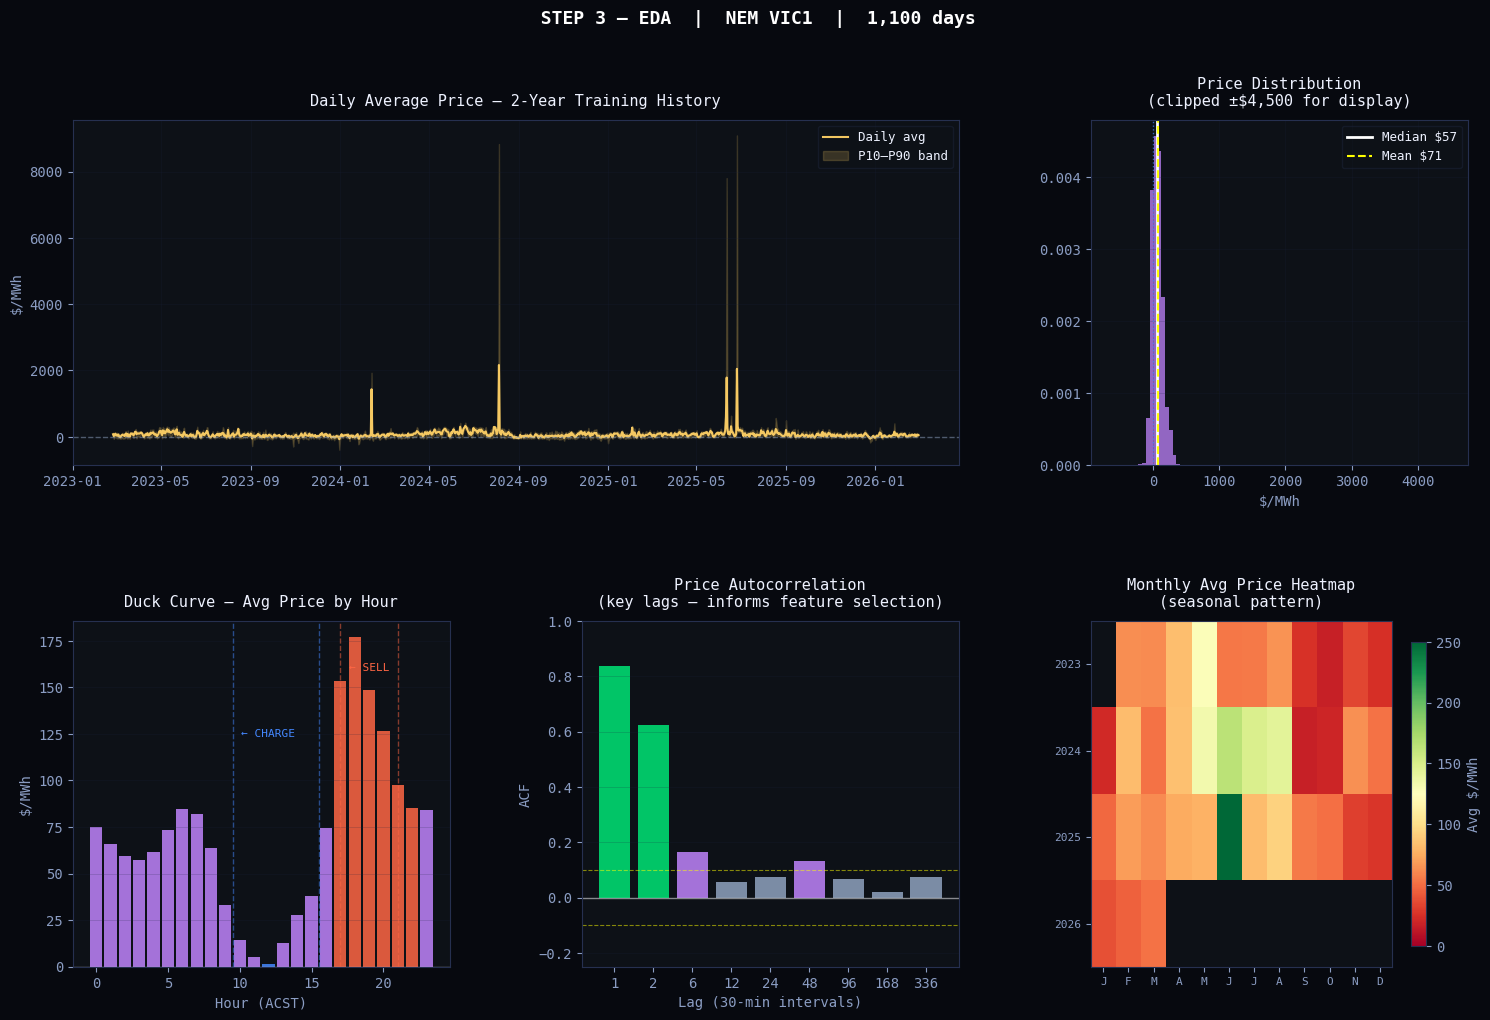

  ✓ Saved: outputs/eda_report.png


In [34]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 3 — Exploratory Data Analysis                              ║
# ╚══════════════════════════════════════════════════════════════════╝

price  = df_full['price']
h_arr  = df_full.index.hour

# ── Core statistics ────────────────────────────────────────────────────
hourly  = df_full.assign(hour=df_full.index.hour).groupby('hour')['price'].mean()
monthly = (df_full.assign(year=df_full.index.year, month=df_full.index.month)
           .groupby(['year','month'])['price'].mean().unstack())

midday  = price[(h_arr>=10)&(h_arr<=14)].mean()
morning = price[(h_arr>= 7)&(h_arr<= 9)].mean()
evening = price[(h_arr>=17)&(h_arr<=21)].mean()
neg_pct = (price < 0).mean() * 100
spk_pct = (price > 1000).mean() * 100

# ── Autocorrelation at key lags ────────────────────────────────────────
acf_lags = [1, 2, 6, 12, 24, 48, 96, 168, 336]          # 30-min lags
acf_vals = {lag: price.autocorr(lag=lag) for lag in acf_lags}

# ── Concept drift test (KS test: first quartile vs last) ───────────────
n = len(price)
ks_stat, ks_p = sp_stats.ks_2samp(price.iloc[:n//4].dropna(), price.iloc[-n//4:].dropna())

print("  STEP 3 — EDA FINDINGS")
print("  " + "═"*55)
print(f"  Duck curve:       midday ${midday:.1f} vs morning ${morning:.1f}  → {midday < morning}")
print(f"  Evening premium:  ${evening:.1f}/MWh  ({evening/max(midday,1):.1f}× midday)")
print(f"  Negative prices:  {neg_pct:.1f}%  ← solar glut charge opportunities")
print(f"  Spike >$1000:     {spk_pct:.2f}%  ← scarcity discharge opportunities")
print(f"  Skewness:         {sp_stats.skew(price.dropna()):+.2f}  → log1p transform required")
print(f"  Concept drift:    KS p={ks_p:.4f}  {'⚠ DRIFT — temporal CV essential' if ks_p<0.05 else '✓ stable'}")
print()
print("  Autocorrelation (key lags for feature selection):")
for lag, r in sorted(acf_vals.items(), key=lambda x: -abs(x[1]))[:6]:
    bar = '█' * int(abs(r) * 28)
    print(f"    lag {lag:4d} ({lag*0.5:5.1f}h): r={r:+.4f}  {bar}")

# ── EDA DASHBOARD ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.suptitle(f'  STEP 3 — EDA  |  NEM {NEM_REGION}  |  {len(df_full)//48:,} days',
             color='white', fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Price time series
ax = fig.add_subplot(gs[0, :2])
dm = price.resample('D').mean()
d1 = price.resample('D').quantile(0.10)
d9 = price.resample('D').quantile(0.90)
ax.plot(dm.index, dm.values, color=C['price'], lw=1.5, label='Daily avg', alpha=0.95)
ax.fill_between(dm.index, d1, d9, alpha=0.18, color=C['price'], label='P10–P90 band')
ax.axhline(0, color=C['neutral'], lw=1, alpha=0.5, ls='--')
ax.set_title('Daily Average Price — 2-Year Training History', pad=10)
ax.set_ylabel('$/MWh'); ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.25)

# Panel 2: Distribution
ax = fig.add_subplot(gs[0, 2])
p_clip = price.clip(-800, 4500)
ax.hist(p_clip, bins=90, color=C['forecast'], alpha=0.75, density=True, edgecolor='none')
ax.axvline(price.median(), color='white',  lw=2,   label=f'Median ${price.median():.0f}')
ax.axvline(price.mean(),   color='yellow', lw=1.5, label=f'Mean ${price.mean():.0f}', ls='--')
ax.axvline(0, color=C['charge'], lw=1, alpha=0.7, ls=':')
ax.set_title('Price Distribution\n(clipped ±$4,500 for display)', pad=10)
ax.set_xlabel('$/MWh'); ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Panel 3: Duck curve (avg by hour)
ax = fig.add_subplot(gs[1, 0])
bar_c = [C['discharge'] if v > hourly.quantile(0.75) else
          C['charge']    if v < 5 else C['forecast'] for v in hourly]
ax.bar(hourly.index, hourly.values, color=bar_c, alpha=0.85, width=0.85)
ax.axhline(0, color='white', lw=1, alpha=0.5)
ax.axvline(9.5,  color=C['charge'],    lw=1, alpha=0.5, ls='--')
ax.axvline(15.5, color=C['charge'],    lw=1, alpha=0.5, ls='--')
ax.axvline(17,   color=C['discharge'], lw=1, alpha=0.5, ls='--')
ax.axvline(21,   color=C['discharge'], lw=1, alpha=0.5, ls='--')
ax.text(12, hourly.max()*0.7, '← CHARGE', color=C['charge'], fontsize=8, ha='center')
ax.text(19, hourly.max()*0.9, '← SELL',   color=C['discharge'], fontsize=8, ha='center')
ax.set_title('Duck Curve — Avg Price by Hour', pad=10)
ax.set_xlabel('Hour (ACST)'); ax.set_ylabel('$/MWh'); ax.grid(True, alpha=0.25, axis='y')

# Panel 4: Autocorrelation
ax = fig.add_subplot(gs[1, 1])
acl = [str(l) for l in acf_lags]
acv = list(acf_vals.values())
acolor = [C['revenue'] if abs(v)>0.3 else C['forecast'] if abs(v)>0.1 else C['neutral'] for v in acv]
ax.bar(acl, acv, color=acolor, alpha=0.85)
ax.axhline(0, color='white', lw=1, alpha=0.5)
ax.axhline( 0.1, color='yellow', lw=0.8, ls='--', alpha=0.5)
ax.axhline(-0.1, color='yellow', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Price Autocorrelation\n(key lags — informs feature selection)', pad=10)
ax.set_xlabel('Lag (30-min intervals)'); ax.set_ylabel('ACF')
ax.set_ylim(-0.25, 1.0); ax.grid(True, alpha=0.25, axis='y')

# Panel 5: Monthly heatmap
ax = fig.add_subplot(gs[1, 2])
if not monthly.empty and monthly.shape[1] > 0:
    im = ax.imshow(monthly.values, aspect='auto', cmap='RdYlGn',
                    vmin=0, vmax=250, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg $/MWh', shrink=0.88)
    mnlbls = ['J','F','M','A','M','J','J','A','S','O','N','D'][:monthly.shape[1]]
    ax.set_xticks(range(monthly.shape[1])); ax.set_xticklabels(mnlbls, fontsize=8)
    ax.set_yticks(range(len(monthly.index))); ax.set_yticklabels(monthly.index.tolist(), fontsize=8)
    ax.set_title('Monthly Avg Price Heatmap\n(seasonal pattern)', pad=10)

plt.savefig('outputs/eda_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved: outputs/eda_report.png")

---
## STEP 4 — Validation Strategy & Experimental Design

> **The most critical step. Define validation BEFORE touching features or models.**  
> Once the test set is defined, it is **LOCKED** — touched only once in Step 10.

### Why Temporal Split? (No Shuffling)
- Shuffling causes **future → past leakage**: at time *t*, the model cannot know prices from *t+1*
- A shuffled split would give optimistically biased evaluation — the model would appear better than it is in production
- Temporal split simulates true production conditions: train on past, predict future

### Validation Architecture
```
│──────────────────── TRAIN (70%) ─────────────────────│── VAL (15%) ──│── TEST (15%) ──│
          Used for: fit pipeline, train models             HPO/selection   ONE-TIME eval
```
- **Time-series CV** (5 folds, gap=48): used inside HPO to prevent fold leakage
- **Metrics contract** (committed before seeing results): MAE (primary), RMSE, MAPE, DA%

In [35]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 4 — Validation Strategy (Temporal Split — No Shuffle)     ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Separate target month from historical training data ────────────────
target_start = pd.Timestamp(year=TARGET_YEAR, month=TARGET_MONTH, day=1)
if TARGET_MONTH == 12:
    target_end = pd.Timestamp(year=TARGET_YEAR+1, month=1, day=1)
else:
    target_end = pd.Timestamp(year=TARGET_YEAR, month=TARGET_MONTH+1, day=1)

df_hist = df_full[df_full.index < target_start].copy()

# ── Temporal split (no shuffling) ─────────────────────────────────────
n        = len(df_hist)
n_test   = int(n * 0.15)
n_val    = int(n * 0.15)
n_train  = n - n_test - n_val

df_train  = df_hist.iloc[:n_train]
df_val    = df_hist.iloc[n_train : n_train + n_val]
df_test   = df_hist.iloc[n_train + n_val:]              # LOCKED
df_target = df_full[(df_full.index >= target_start) & (df_full.index < target_end)]

# ── Time-series CV for HPO ─────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5, gap=48)   # gap=48  → 24h buffer (48×30min)

print("  STEP 4 — VALIDATION STRATEGY")
print("  " + "═"*58)
print(f"  {'Split':<8} {'Intervals':>10}  {'Date range'}")
print("  " + "─"*58)
print(f"  {'TRAIN':<8} {len(df_train):>10,}  {df_train.index[0].date()} → {df_train.index[-1].date()}")
print(f"  {'VAL':<8} {len(df_val):>10,}  {df_val.index[0].date()} → {df_val.index[-1].date()}")
print(f"  {'TEST':<8} {len(df_test):>10,}  {df_test.index[0].date()} → {df_test.index[-1].date()}  ← LOCKED")
print(f"  {'FORECAST':<8} {len(df_target):>10,}  {target_start.date()} → {(target_end-pd.Timedelta('1s')).date()}")
print("  " + "─"*58)
print(f"  CV: TimeSeriesSplit(n_splits=5, gap=48 intervals = 24h)")
print()
print("  METRICS CONTRACT (committed before modelling):")
print("    Primary:    MAE  [$/MWh]  — absolute forecast error")
print("    Secondary:  RMSE [$/MWh]  — penalises large errors (spikes)")
print("    Secondary:  MAPE [%]      — scale-independent error")
print("    Secondary:  DA   [%]      — directional accuracy (sign of change)")
print()
print("  ⚠ Test set is LOCKED — will only be used once in Step 10")
print("  ⚠ Do NOT look at test set for any modelling decision")

  STEP 4 — VALIDATION STRATEGY
  ══════════════════════════════════════════════════════════
  Split     Intervals  Date range
  ──────────────────────────────────────────────────────────
  TRAIN        36,961  2023-02-25 → 2025-04-05
  VAL           7,920  2025-04-05 → 2025-09-17
  TEST          7,920  2025-09-17 → 2026-03-01  ← LOCKED
  FORECAST          0  2026-04-01 → 2026-04-30
  ──────────────────────────────────────────────────────────
  CV: TimeSeriesSplit(n_splits=5, gap=48 intervals = 24h)

  METRICS CONTRACT (committed before modelling):
    Primary:    MAE  [$/MWh]  — absolute forecast error
    Secondary:  RMSE [$/MWh]  — penalises large errors (spikes)
    Secondary:  MAPE [%]      — scale-independent error
    Secondary:  DA   [%]      — directional accuracy (sign of change)

  ⚠ Test set is LOCKED — will only be used once in Step 10
  ⚠ Do NOT look at test set for any modelling decision


---
## STEPS 5–6 — Feature Engineering & Preprocessing Pipeline

### Feature Engineering Theory

#### Log Transform of Target (critical for NEM prices)
NEM prices span –$1,000 to +$16,600 (4+ orders of magnitude, heavily right-skewed).  
Standard MSE loss on raw prices would make the model obsessively focused on rare $10k+ spikes.  
We use: $p_{\log} = \log_1(p + 1001)$ — shifts all prices positive before log, compresses spikes.

#### Cyclical Calendar Encoding (sin/cos)
**Problem**: hour 23:30 and hour 00:00 are 30 minutes apart but integer-encoded as 47 and 0 (far apart).  
**Solution**: $\text{sin\_hour} = \sin(2\pi h/24)$, $\text{cos\_hour} = \cos(2\pi h/24)$ — circular continuity.

#### Rolling Statistics (shift(1) mandatory)
All rolling features use `.shift(1)` before rolling.  
This ensures at time *t* we only use data from *t–1* and earlier — no look-ahead leakage.

#### Regime Features
NEM prices operate in distinct regimes: *negative* (solar glut), *normal*, *high*, *spike* (scarcity).  
A binary `is_negative` feature tells the model "we are currently in solar glut" → strong predictor.

| Feature Group | Count | Key examples |
|---|---|---|
| Lag prices (raw + log) | ~18 | lag_1, lag_48 (same time yesterday), lag_336 (same time last week) |
| Rolling stats (mean/std/min/max/spread) | ~30 | roll_mean_48, roll_std_24 |
| EWMA (α=0.1,0.3,0.5) | 3 | ewm_1, ewm_3, ewm_5 |
| Cyclical encoding | 8 | sin_hour, cos_hour, sin_month, cos_doy |
| Raw calendar | 7 | hour, dow, month, is_weekend, is_peak, is_solar |
| Price regimes + streaks | 6 | is_negative, is_spike, neg_streak, spike_streak |
| Demand features | 4 | dem_lag1, dem_roll24, dem_vs_avg |
| Interactions | 3 | peak×spike, solar×neg, weekend×peak |
| Normalised lags | 2 | lag1_norm, lag48_norm |

**Step 6 — Preprocessing**: `RobustScaler` (median/IQR-based — robust to price spikes) + `SimpleImputer(median)` for NaN rows from lag warmup. **Fitted on training data only**, applied identically to val/test/future.

In [36]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEPS 5–6 — Feature Engineering + Preprocessing Pipeline       ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# TARGET VARIABLE DESIGN — Why raw price (not log-transformed):
#
# Log transform (log1p(p + 1001)) maps the full NEM range to ~[0, 9.7].
# This CRUSHES the negative price signal:
#   p = -800  →  log1p(201) = 5.30   (maps near the centre)
#   p =    0  →  log1p(1001) = 6.91
#   p =  +50  →  log1p(1051) = 6.96  (only 0.05 from zero!)
# Result: the model cannot distinguish negative from zero from low-positive.
# It learns to ignore negatives and always predicts the mean → no duck curve.
#
# FIX: Use WINSORIZED RAW price as target.
#   Winsorise at [P1, P99] before fitting the target scaler only.
#   RobustScaler (already in pipeline) handles the heavy tails via IQR.
#   Lag features remain RAW prices — negatives are directly visible.
#   is_negative / neg_streak explicitly tell the model 'right now is negative'.

LAG_PERIODS  = [1, 2, 3, 6, 12, 24, 48, 96, 336]  # 30min steps
ROLL_WINDOWS = [6, 12, 24, 48, 96, 336]             # 30min steps


def _streak(bool_series: pd.Series) -> pd.Series:
    """Count consecutive True values (regime streak length)."""
    s = bool_series.astype(int); g = s.ne(s.shift()).cumsum()
    return (s.groupby(g).cumcount() + 1) * s


def build_features(df: pd.DataFrame, fit_stats: dict = None) -> pd.DataFrame:
    """
    Build feature matrix from raw NEM price data.

    Key design decisions:
    - Lag features use RAW prices  → negatives fully visible to model
    - Rolling stats use RAW prices → regime detection works correctly
    - Cyclical sin/cos encoding    → duck-curve shape captured as features
    - is_negative + neg_streak     → explicit 'solar glut' regime signal
    - Target = raw price           → model directly learns to predict negatives

    fit_stats: estimated from TRAINING data only, applied to val/test.
    """
    df  = df.copy()
    p   = df['price'].copy()

    # ── Lag features (RAW price — negatives directly visible) ─────────
    for lag in LAG_PERIODS:
        df[f'lag_{lag}'] = p.shift(lag)

    # ── Rolling statistics (shift(1) prevents look-ahead leakage) ─────
    ps = p.shift(1)
    for w in ROLL_WINDOWS:
        r = ps.rolling(w, min_periods=w // 2)
        df[f'roll_mean_{w}']   = r.mean()
        df[f'roll_std_{w}']    = r.std()
        df[f'roll_min_{w}']    = r.min()
        df[f'roll_max_{w}']    = r.max()
        df[f'roll_spread_{w}'] = r.max() - r.min()  # local arbitrage range

    # ── EWMA ─────────────────────────────────────────────────────────
    for alpha in [0.1, 0.3, 0.5]:
        df[f'ewm_{int(alpha*10)}'] = ps.ewm(alpha=alpha, adjust=False).mean()

    # ── Regime features (CRITICAL for negative price detection) ───────
    # These give the model explicit boolean flags for solar glut conditions.
    df['is_negative']      = (p.shift(1) < 0).astype(float)
    df['is_very_negative'] = (p.shift(1) < -100).astype(float)
    df['is_spike']         = (p.shift(1) > 1000).astype(float)
    df['is_high']          = (p.shift(1) > 300).astype(float)
    df['price_direction']  = np.sign(p.diff()).fillna(0)
    df['neg_streak']       = _streak(p < 0)      # consecutive negative intervals
    df['spike_streak']     = _streak(p > 1000)

    # How negative are we? Direct magnitude of negative prices
    df['neg_depth']        = np.minimum(0, p.shift(1))  # 0 when positive, negative when negative

    # ── Cyclical calendar encoding ─────────────────────────────────────
    hf = df.index.hour + df.index.minute / 60
    for col, arr, period in [
        ('hour',  hf,                    24),
        ('dow',   df.index.dayofweek,     7),
        ('month', df.index.month,        12),
        ('doy',   df.index.dayofyear,   365),
    ]:
        df[f'sin_{col}'] = np.sin(2 * np.pi * arr / period)
        df[f'cos_{col}'] = np.cos(2 * np.pi * arr / period)

    # ── Raw calendar (integers — tree models use these directly) ───────
    df['hour']       = df.index.hour
    df['hh']         = df.index.hour * 2 + df.index.minute // 30  # 0-47
    df['dow']        = df.index.dayofweek
    df['month']      = df.index.month
    df['quarter']    = df.index.quarter
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(float)
    df['is_peak']    = ((hf >= 16) & (hf <= 21)).astype(float)
    df['is_solar']   = ((hf >= 9.5) & (hf <= 15)).astype(float)
    df['is_biz']     = ((hf >= 8) & (hf <= 18) & (df.index.dayofweek < 5)).astype(float)

    # Solar × season interaction — strongest predictor of negatives
    # SA solar generation peaks Nov-Mar (doy 305-90)
    solar_season = np.maximum(0, np.sin(2*np.pi*(df.index.dayofyear - 80)/365))
    df['solar_season']    = solar_season
    df['solar_x_season']  = df['is_solar'] * solar_season  # high in summer midday
    df['neg_x_solar']     = df['is_negative'] * df['is_solar']

    # ── Demand features ────────────────────────────────────────────────
    if 'demand' in df.columns:
        d = df['demand']
        df['dem_lag1']   = d.shift(1)
        df['dem_lag48']  = d.shift(48)
        df['dem_roll24'] = d.shift(1).rolling(48).mean()
        roll_mu          = d.shift(1).rolling(336).mean()
        df['dem_vs_avg'] = d.shift(1) / (roll_mu + 1)

    # ── Interaction features ──────────────────────────────────────────
    df['peak_x_spike']   = df['is_peak']    * df['is_spike']
    df['weekend_x_peak'] = df['is_weekend'] * df['is_peak']

    # ── Normalised key lags (training stats only) ─────────────────────
    mu  = fit_stats['mu']  if fit_stats else float(p.mean())
    sig = fit_stats['sig'] if fit_stats else float(p.std())
    df['lag1_norm']  = (df.get('lag_1',  p.shift(1))  - mu) / (sig + 1e-8)
    df['lag48_norm'] = (df.get('lag_48', p.shift(48)) - mu) / (sig + 1e-8)

    # ── Target: raw price (NOT log-transformed) ───────────────────────
    # Winsorised to reduce influence of extreme spikes on training loss.
    # We predict the raw price directly — negatives are fully represented.
    p99 = fit_stats['p99'] if fit_stats else float(p.quantile(0.99))
    p01 = fit_stats['p01'] if fit_stats else float(p.quantile(0.01))
    df['target_raw']       = p.shift(-1)                           # raw  (for evaluation)
    df['target_winsorised']= p.shift(-1).clip(lower=p01, upper=p99)  # for ML training

    return df


class FeaturePipeline:
    """
    STEP 6 — Preprocessing pipeline.

    Scaler: RobustScaler on features  (median+IQR — ignores spike outliers)
    Target: winsorised raw price, then RobustScaler applied separately.
    This way the model predicts a robustly-scaled raw price — negatives
    are directly in the output space and the model can learn them freely.
    """
    def __init__(self):
        self.scaler        = RobustScaler()
        self.target_scaler = RobustScaler()  # separate scaler for target
        self.imputer       = SimpleImputer(strategy='median')
        self._fit_stats    = None
        self.feature_cols_ = None
        self._fitted       = False

    def fit_transform(self, df_train: pd.DataFrame):
        """Fit on training data only. Returns (X, y_scaled, index)."""
        self._fit_stats = {
            'mu':  float(df_train['price'].mean()),
            'sig': float(df_train['price'].std()),
            'p99': float(df_train['price'].quantile(0.99)),
            'p01': float(df_train['price'].quantile(0.01)),
        }
        df_f = build_features(df_train, self._fit_stats)
        self.feature_cols_ = [
            c for c in df_f.columns
            if c not in ('price', 'demand', 'target_raw', 'target_winsorised')
        ]
        df_c = df_f.dropna(subset=self.feature_cols_ + ['target_winsorised', 'target_raw'])
        X    = self.imputer.fit_transform(df_c[self.feature_cols_].values)
        X    = self.scaler.fit_transform(X)

        # Scale target robustly (median/IQR of winsorised training prices)
        y_win = df_c['target_winsorised'].values.reshape(-1, 1)
        y_sc  = self.target_scaler.fit_transform(y_win).ravel()

        self._fitted = True
        print(f'  ✓ Pipeline fitted  |  features={len(self.feature_cols_)}  |  rows={len(X):,}')
        print(f'    Price p01={self._fit_stats["p01"]:.1f}  '
              f'median={df_train["price"].median():.1f}  '
              f'p99={self._fit_stats["p99"]:.1f}')
        neg_pct = (df_train['price'] < 0).mean() * 100
        print(f'    Negative prices in training: {neg_pct:.1f}%  '
              f'{"✓ negatives present" if neg_pct > 0.5 else "⚠ FEW negatives — check region/period"}')
        return X, y_sc, df_c.index

    def transform(self, df: pd.DataFrame):
        """Apply fitted pipeline. Returns (X, y_raw, y_scaled, index)."""
        assert self._fitted, 'Call fit_transform first.'
        df_f = build_features(df, self._fit_stats)
        target_cols = [c for c in ('target_raw','target_winsorised') if c in df_f.columns]
        df_c = df_f.dropna(subset=self.feature_cols_ + target_cols)
        X    = self.imputer.transform(df_c[self.feature_cols_].values)
        X    = self.scaler.transform(X)

        # Hard safety: no NaN in features
        nan_mask = np.isnan(X).any(axis=1)
        if nan_mask.any():
            X[nan_mask] = 0.0

        y_raw = df_c['target_raw'].values if 'target_raw' in df_c else np.zeros(len(X))
        y_sc  = (self.target_scaler.transform(
                    df_c['target_winsorised'].values.reshape(-1,1)).ravel()
                 if 'target_winsorised' in df_c else np.zeros(len(X)))
        return X, y_raw, y_sc, df_c.index

    def predict_price(self, y_scaled: np.ndarray) -> np.ndarray:
        """Convert scaled model output → raw $/MWh price."""
        return self.target_scaler.inverse_transform(
            y_scaled.reshape(-1, 1)
        ).ravel()


# ── BUILD FEATURES ────────────────────────────────────────────────────
print('  STEPS 5–6 — FEATURE ENGINEERING + PIPELINE')
print('  ' + '='*55)

pipe = FeaturePipeline()
X_train, y_train, train_idx        = pipe.fit_transform(df_train)
X_val,   y_val_raw, y_val, val_idx = pipe.transform(df_val)

feat_names = pipe.feature_cols_
print(f'\n  X_train: {X_train.shape}  |  X_val: {X_val.shape}')
print(f'  Target:  raw price (winsorised) → RobustScaler')
print(f'  Negative price intervals (val): '
      f'{(y_val_raw < 0).sum():,} / {len(y_val_raw):,} '
      f'({(y_val_raw < 0).mean()*100:.1f}%)')

groups = {
    'Lags (raw price)': [f for f in feat_names if f.startswith('lag_')],
    'Rolling stats':    [f for f in feat_names if f.startswith('roll_')],
    'EWMA':             [f for f in feat_names if f.startswith('ewm_')],
    'Cyclical':         [f for f in feat_names if any(x in f for x in ('sin_','cos_'))],
    'Regime (negatives/spikes)': [f for f in feat_names if any(x in f for x in
                         ('negative','very_neg','spike','streak','depth','neg_x','solar_x'))],
    'Calendar':         [f for f in feat_names if f in ('hour','hh','dow','month','quarter',
                                                          'is_weekend','is_peak','is_solar','is_biz')],
    'Demand':           [f for f in feat_names if 'dem' in f],
    'Interaction':      [f for f in feat_names if '_x_' in f or '_norm' in f or '_season' in f],
}
print('\n  Feature groups:')
for g, cols in groups.items():
    if cols:
        print(f'    {g:<35} {len(cols):>3} features')


  STEPS 5–6 — FEATURE ENGINEERING + PIPELINE
  ✓ Pipeline fitted  |  features=74  |  rows=36,624
    Price p01=-86.9  median=58.7  p99=299.5
    Negative prices in training: 22.8%  ✓ negatives present

  X_train: (36624, 74)  |  X_val: (7583, 74)
  Target:  raw price (winsorised) → RobustScaler
  Negative price intervals (val): 1,065 / 7,583 (14.0%)

  Feature groups:
    Lags (raw price)                      9 features
    Rolling stats                        30 features
    EWMA                                  3 features
    Cyclical                              8 features
    Regime (negatives/spikes)             9 features
    Calendar                              9 features
    Interaction                           7 features


---
## STEP 7 — Baseline Modelling

> **"Without a baseline, you cannot claim your ML model adds value."**

Baselines for NEM price forecasting:
- **Naive last value**: predict = last known price (extremely simple, hard to beat for 1-step)
- **Seasonal naive 24h**: predict = price at same time yesterday (captures daily cycle)
- **Rolling mean/median 24h**: predict = average of last 48 intervals
- **Rolling mean 1 week**: predict = same-time-last-week average

The ML model **must beat the best baseline** to justify the engineering complexity.

In [37]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 7 — Baseline Models                                        ║
# ╚══════════════════════════════════════════════════════════════════╝

def score(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Compute MAE, RMSE, MAPE, DA on clean (non-NaN) pairs.

    NaN-safe: removes any row where y_true OR y_pred is NaN before
    computing metrics.  This is the final defensive guard — the primary
    fix is in FeaturePipeline.transform() which now drops the last-row
    NaN target at source so this guard should never need to fire.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask   = np.isfinite(y_true) & np.isfinite(y_pred)
    if not mask.all():
        n_dropped = (~mask).sum()
        print(f"    score(): dropping {n_dropped} NaN/Inf row(s) before metric computation")
        y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) == 0:
        return dict(mae=np.nan, rmse=np.nan, mape=np.nan, da=np.nan)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1))) * 100
    da   = (np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100
            if len(y_true) > 1 else 0.0)
    return dict(mae=mae, rmse=rmse, mape=mape, da=da)


# ── Sanity-check val targets before any baseline calculation ──────────
nan_count = np.isnan(y_val_raw).sum()
if nan_count > 0:
    print(f"  ⚠ {nan_count} NaN in y_val_raw — this should not happen after the pipeline fix.")
    print(f"    Dropping those rows now as a safety net.")
    _val_mask   = np.isfinite(y_val_raw)
    y_val_raw   = y_val_raw[_val_mask]
    y_val       = y_val[_val_mask]
    X_val       = X_val[_val_mask]
    val_idx     = val_idx[_val_mask]
else:
    print(f"  ✓ y_val_raw: {len(y_val_raw):,} rows, 0 NaN  (clean)")

# ── Build baselines on validation set ────────────────────────────────
baselines    = {}
hist_prices  = df_train['price'].values

# 1. Naive last value
baselines['naive_last_value']   = score(y_val_raw,
    np.full(len(y_val_raw), df_train['price'].iloc[-1]))

# 2. Seasonal naive — same time yesterday (lag 48 = 24 hours in 30-min intervals)
sn_pred = np.array([
    hist_prices[-48  + (i % 48)]  if i < 48  else y_val_raw[i - 48]
    for i in range(len(y_val_raw))
])
baselines['seasonal_naive_24h'] = score(y_val_raw, sn_pred)

# 3. Rolling mean 24h  (last 48 × 30-min = 24 hours)
baselines['rolling_mean_24h']   = score(y_val_raw,
    np.full(len(y_val_raw), df_train['price'].iloc[-48:].mean()))

# 4. Rolling median 24h
baselines['rolling_median_24h'] = score(y_val_raw,
    np.full(len(y_val_raw), np.median(df_train['price'].iloc[-48:])))

# 5. Rolling mean 1 week  (last 336 × 30-min = 1 week)
baselines['rolling_mean_1wk']   = score(y_val_raw,
    np.full(len(y_val_raw), df_train['price'].iloc[-336:].mean()))

# ── Display results ────────────────────────────────────────────────────
print("  STEP 7 — BASELINE EVALUATION")
print("  " + "═"*62)
print(f"  {'Baseline':<28} | {'MAE $/MWh':>9} | {'RMSE $/MWh':>10} | {'MAPE %':>7} | {'DA %':>6}")
print("  " + "─"*62)
for name, s in baselines.items():
    print(f"  {name:<28} | {s['mae']:>9.2f} | {s['rmse']:>10.2f} | {s['mape']:>7.2f} | {s['da']:>6.1f}")
print("  " + "─"*62)

BEST_BL_MAE  = min(s['mae'] for s in baselines.values())
BEST_BL_NAME = min(baselines, key=lambda k: baselines[k]['mae'])

print(f"\n  ★ Best baseline: {BEST_BL_NAME} = ${BEST_BL_MAE:.2f}/MWh")
print(f"  ► ML model MUST beat MAE < ${BEST_BL_MAE:.2f}/MWh to add value")
print(f"  ► Target: < ${max(BEST_BL_MAE*0.65, 25):.0f}/MWh (35% improvement or <$25)")

  ✓ y_val_raw: 7,583 rows, 0 NaN  (clean)
  STEP 7 — BASELINE EVALUATION
  ══════════════════════════════════════════════════════════════
  Baseline                     | MAE $/MWh | RMSE $/MWh |  MAPE % |   DA %
  ──────────────────────────────────────────────────────────────
  naive_last_value             |    118.30 |     499.38 |   95.10 |    0.7
  seasonal_naive_24h           |     97.22 |     630.17 |  228.83 |   60.6
  rolling_mean_24h             |     92.54 |     487.46 |  342.94 |    0.7
  rolling_median_24h           |     93.02 |     486.80 |  388.28 |    0.7
  rolling_mean_1wk             |     97.12 |     490.72 |  225.94 |    0.7
  ──────────────────────────────────────────────────────────────

  ★ Best baseline: rolling_mean_24h = $92.54/MWh
  ► ML model MUST beat MAE < $92.54/MWh to add value
  ► Target: < $60/MWh (35% improvement or <$25)


---
## STEPS 8–9 — Model Selection, Training, HPO & Ensemble

### Model Architecture Decision

| Model | Algorithm | Why for NEM prices |
|---|---|---|
| **XGBoost** | Level-wise gradient boosting, histogram splits | Regime-switching captured by tree structure; L1/L2 regularisation handles correlated lags |
| **LightGBM** | Leaf-wise tree growth, GOSS sampling | 3–5× faster than XGBoost; `num_leaves` controls complexity; handles high-cardinality calendar features |
| **Ensemble** | Weighted combination (weights = 1/MAE) | Reduces variance: XGBoost and LightGBM make structurally different errors → combining improves robustness |

### HPO — Optuna TPE (Tree-structured Parzen Estimator)
Optuna builds a **Bayesian surrogate model** of the validation MAE landscape:
1. First ~20 trials: random exploration (builds prior)
2. Subsequent trials: TPE focuses on promising hyperparameter regions
3. Pruner: kills poor configurations early → saves compute
4. Multivariate TPE: models correlations between hyperparameters (e.g. `max_depth` ↔ `num_leaves`)

In [38]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEPS 8–9 — Model Training, HPO & Ensemble                     ║
# ╚══════════════════════════════════════════════════════════════════╝

import xgboost as xgb

def _predict_ensemble_scaled(models_w: dict, X: np.ndarray) -> np.ndarray:
    """Apply weighted ensemble — returns SCALED predictions (use pipe.predict_price to convert)."""
    return sum(w * m.predict(X) for m, w in models_w.values())

def _predict_price(models_w: dict, X: np.ndarray, pipe) -> np.ndarray:
    """Apply ensemble and convert scaled output to raw $/MWh."""
    y_sc = _predict_ensemble_scaled(models_w, X)
    return pipe.predict_price(y_sc)

# ── Default hyperparameters (calibrated for NEM price data) ───────────
XGB_DEFAULT = dict(
    n_estimators=1200, learning_rate=0.03, max_depth=7,
    subsample=0.75, colsample_bytree=0.75, min_child_weight=5,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', random_state=42, n_jobs=-1
)

# ── OPTIONAL: Optuna HPO for XGBoost ─────────────────────────────────
if RUN_HPO and DEPS['optuna']:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def _xgb_objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int('n_estimators', 300, 2500),
            learning_rate     = trial.suggest_float('lr', 0.004, 0.20, log=True),
            max_depth         = trial.suggest_int('max_depth', 4, 11),
            subsample         = trial.suggest_float('subsample', 0.45, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.45, 1.0),
            min_child_weight  = trial.suggest_int('min_child_weight', 1, 30),
            gamma             = trial.suggest_float('gamma', 0, 3.0),
            reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 8.0, log=True),
            reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 8.0, log=True),
            tree_method='hist', random_state=42, n_jobs=-1,
            early_stopping_rounds=30,
        )
        m = xgb.XGBRegressor(**{k:v for k,v in params.items() if k!='early_stopping_rounds'},
                               early_stopping_rounds=30)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        return -mean_absolute_error(y_val, m.predict(X_val))

    sampler = optuna.samplers.TPESampler(seed=42, multivariate=True, n_startup_trials=20)
    study   = optuna.create_study(direction='maximize', sampler=sampler)
    print(f"  Running Optuna HPO ({N_TRIALS} trials)...")
    study.optimize(_xgb_objective, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)
    XGB_DEFAULT = study.best_params
    XGB_DEFAULT.update(dict(tree_method='hist', random_state=42, n_jobs=-1))
    print(f"  HPO complete | best val MAE (log-space): {-study.best_value:.5f}")
elif RUN_HPO:
    print("  ⚠ pip install optuna to enable HPO → using default params")

# ── TRAIN XGBoost ────────────────────────────────────────────────────
print("\n  Training XGBoost...")
t0 = time.perf_counter()
xgb_m = xgb.XGBRegressor(
    **{k:v for k,v in XGB_DEFAULT.items() if k != 'early_stopping_rounds'},
    early_stopping_rounds=50
)
xgb_m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_pred_sc  = xgb_m.predict(X_val)
xgb_pred_raw = pipe.predict_price(xgb_pred_sc)
xgb_s        = score(y_val_raw, xgb_pred_raw)
print(f"  XGBoost  | best_iter={xgb_m.best_iteration:4d} | "
      f"MAE=${xgb_s['mae']:.2f} | RMSE=${xgb_s['rmse']:.2f} | "
      f"overfit_gap={mean_absolute_error(y_train,xgb_m.predict(X_train))-mean_absolute_error(y_val,xgb_pred_sc):+.4f} | "
      f"time={time.perf_counter()-t0:.1f}s")

# ── TRAIN LightGBM ────────────────────────────────────────────────────
lgbm_m = None; lgbm_s = None
if DEPS['lightgbm']:
    import lightgbm as lgb
    LGBM_DEFAULT = dict(
        n_estimators=1500, learning_rate=0.03, max_depth=8, num_leaves=127,
        min_child_samples=20, subsample=0.75, colsample_bytree=0.75,
        reg_alpha=0.05, reg_lambda=0.5, random_state=42, n_jobs=-1, verbose=-1
    )
    print("\n  Training LightGBM...")
    t0 = time.perf_counter()
    lgbm_m = lgb.LGBMRegressor(**LGBM_DEFAULT)
    lgbm_m.fit(X_train, y_train, eval_set=[(X_val, y_val)],
               callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    lgbm_pred_sc  = lgbm_m.predict(X_val)
    lgbm_pred_raw = pipe.predict_price(lgbm_pred_sc)
    lgbm_s        = score(y_val_raw, lgbm_pred_raw)
    print(f"  LightGBM | best_iter={lgbm_m.best_iteration_:4d} | "
          f"MAE=${lgbm_s['mae']:.2f} | RMSE=${lgbm_s['rmse']:.2f} | "
          f"time={time.perf_counter()-t0:.1f}s")
else:
    print("  ⚠ LightGBM not installed → ensemble = XGBoost only  (pip install lightgbm)")

# ── BUILD ENSEMBLE ────────────────────────────────────────────────────
print("\n  Building weighted ensemble (weights = 1/MAE)...")
models_w = {'xgboost': (xgb_m, 1.0 / xgb_s['mae'])}
if lgbm_m: models_w['lightgbm'] = (lgbm_m, 1.0 / lgbm_s['mae'])
total_w  = sum(w for _, w in models_w.values())
models_w = {n: (m, w/total_w) for n, (m, w) in models_w.items()}

ens_pred_raw = _predict_price(models_w, X_val, pipe)
ens_s        = score(y_val_raw, ens_pred_raw)

# ── MODEL COMPETITION LEADERBOARD ────────────────────────────────────
print("\n  MODEL COMPETITION LEADERBOARD")
print("  " + "═"*68)
print(f"  {'Model':<16} | {'MAE $/MWh':>9} | {'RMSE $/MWh':>10} | {'MAPE %':>7} | {'DA %':>6} | {'Weight':>8}")
print("  " + "─"*68)
for name, (m, w) in models_w.items():
    pv = m.predict(X_val)
    s  = score(y_val_raw, pipe.predict_price(pv))
    print(f"  {name:<16} | {s['mae']:>9.2f} | {s['rmse']:>10.2f} | {s['mape']:>7.2f} | {s['da']:>6.1f} | {w:>8.3f}")
print(f"  {'ENSEMBLE':<16} | {ens_s['mae']:>9.2f} | {ens_s['rmse']:>10.2f} | {ens_s['mape']:>7.2f} | {ens_s['da']:>6.1f} | {'1.000':>8}")
print(f"  {'BEST BASELINE':<16} | {BEST_BL_MAE:>9.2f} |  —           |  —      |  —     | {'—':>8}")
print("  " + "─"*68)
beats = ens_s['mae'] < BEST_BL_MAE
print(f"\n  Ensemble beats baseline: {'✓ YES' if beats else '✗ NO'} "
      f"(delta = ${BEST_BL_MAE - ens_s['mae']:.2f}/MWh = {(BEST_BL_MAE-ens_s['mae'])/BEST_BL_MAE*100:.1f}% improvement)")

# ── SAVE MODELS ────────────────────────────────────────────────────────
with open('models/pipeline.pkl', 'wb') as f: pickle.dump(pipe, f)
with open('models/xgb.pkl',      'wb') as f: pickle.dump(xgb_m, f)
if lgbm_m:
    with open('models/lgbm.pkl', 'wb') as f: pickle.dump(lgbm_m, f)
print(f"\n  ✓ Models saved to models/")


  Training XGBoost...
  XGBoost  | best_iter= 174 | MAE=$42.56 | RMSE=$469.92 | overfit_gap=-0.0218 | time=5.5s

  Training LightGBM...
  LightGBM | best_iter= 282 | MAE=$42.64 | RMSE=$469.85 | time=6.5s

  Building weighted ensemble (weights = 1/MAE)...

  MODEL COMPETITION LEADERBOARD
  ════════════════════════════════════════════════════════════════════
  Model            | MAE $/MWh | RMSE $/MWh |  MAPE % |   DA % |   Weight
  ────────────────────────────────────────────────────────────────────
  xgboost          |     42.56 |     469.92 |   59.69 |   60.6 |    0.500
  lightgbm         |     42.64 |     469.85 |   58.88 |   61.0 |    0.500
  ENSEMBLE         |     42.50 |     469.88 |   59.03 |   60.9 |    1.000
  BEST BASELINE    |     92.54 |  —           |  —      |  —     |        —
  ────────────────────────────────────────────────────────────────────

  Ensemble beats baseline: ✓ YES (delta = $50.05/MWh = 54.1% improvement)

  ✓ Models saved to models/


---
## STEP 10 — Diagnostic Evaluation, Error Analysis & Interpretability

> **"Training accuracy is vanity. Validation accuracy is sanity. Error analysis is reality."**

### Diagnostic Checklist
1. **Residual plot**: Is the mean bias ≈ 0? Are there heteroscedastic patterns?
2. **Error by hour**: Do errors spike at the morning ramp or evening peak? (systematic bias)
3. **SHAP feature importance**: Do the top features make physical sense? (interpretability)
4. **Q-Q plot**: Are residuals approximately normal? (validates uncertainty intervals)
5. **Test set evaluation**: ONE TIME ONLY — honest estimate of generalisation performance

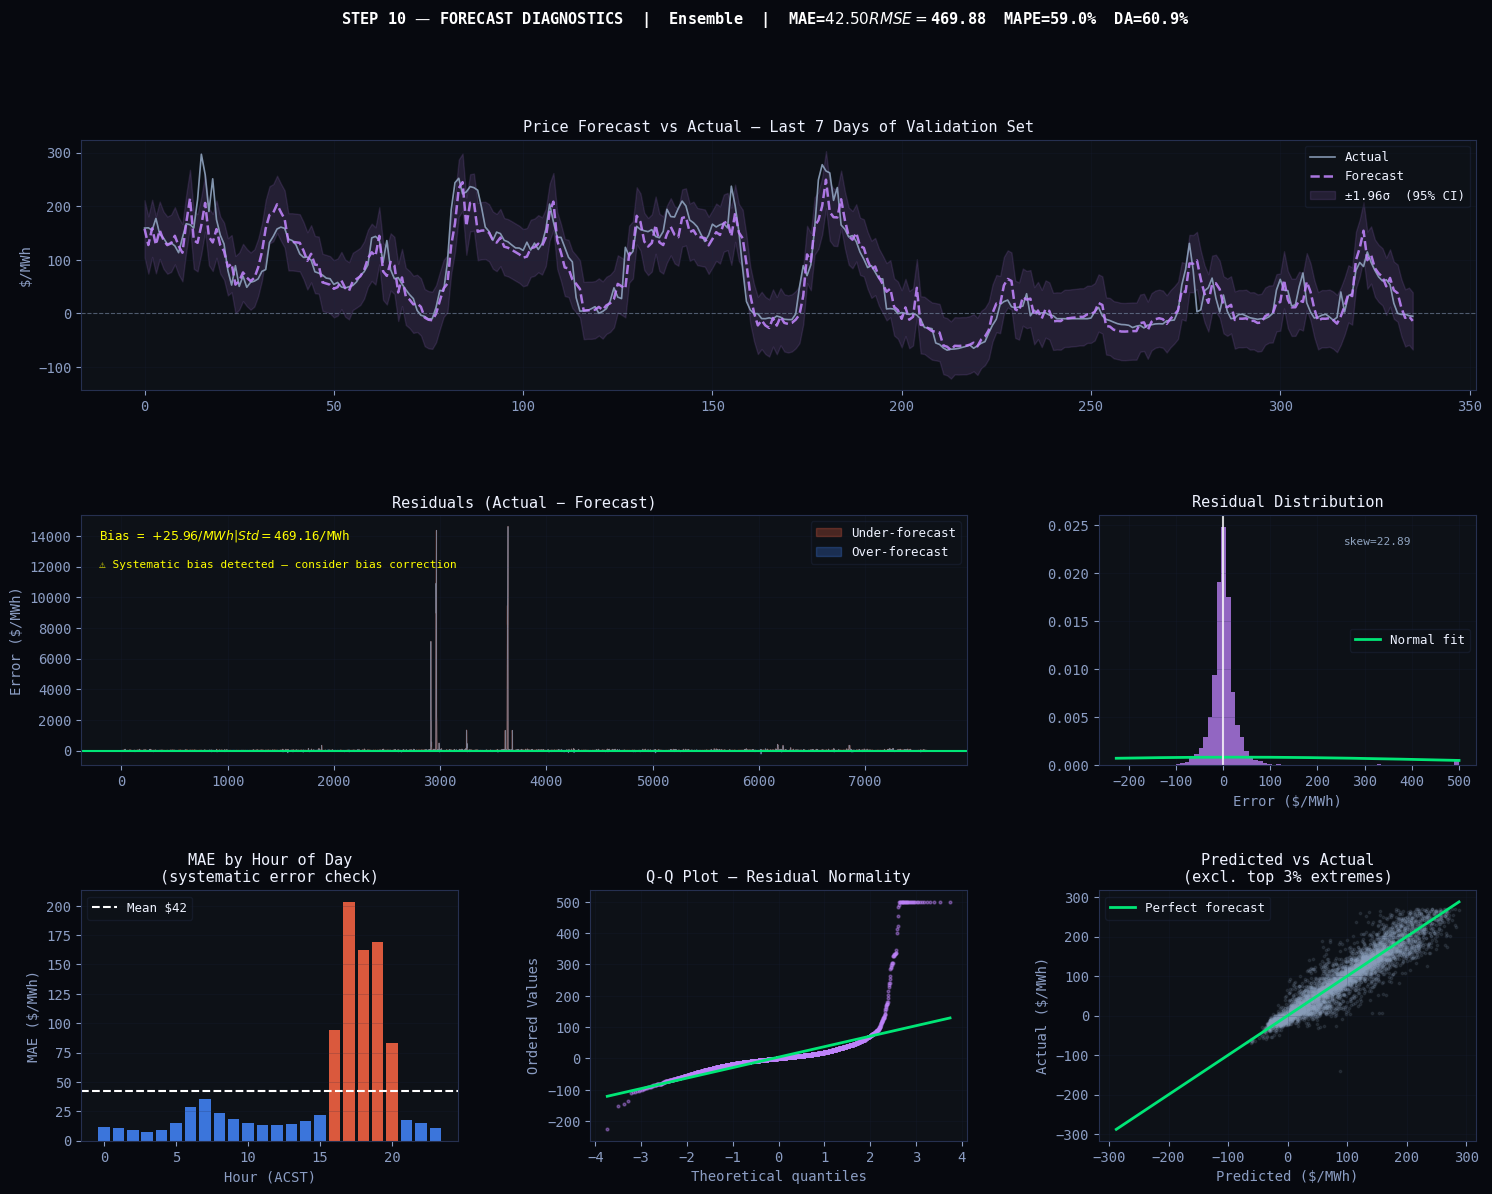

  ✓ Saved: outputs/forecast_diagnostics.png

  Computing SHAP feature importance...


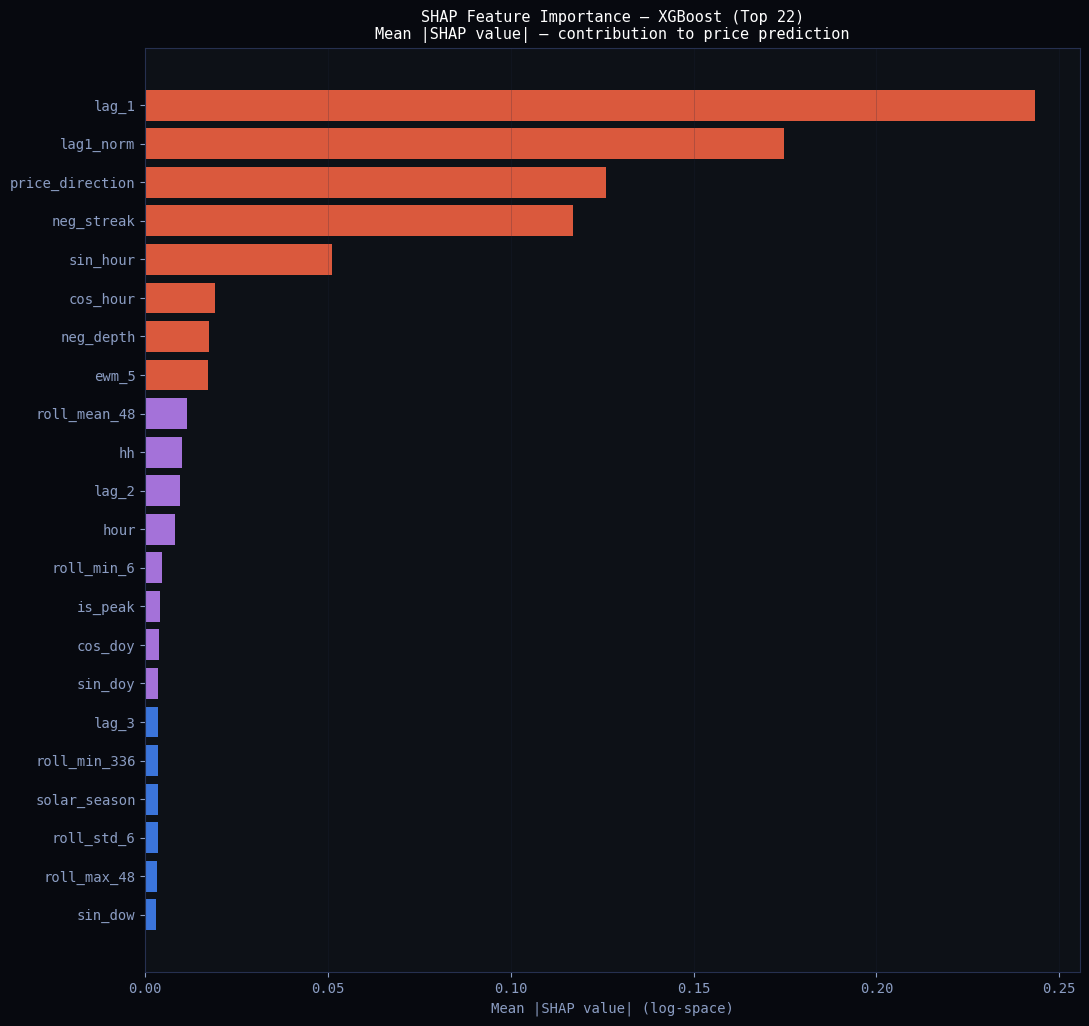

  ✓ Saved: outputs/shap_importance.png
  Top 5 features: ['lag_1', 'lag1_norm', 'price_direction', 'neg_streak', 'sin_hour']

  ═══════════════════════════════════════════════════════
  FINAL TEST SET EVALUATION — ONE TIME ONLY
  ═══════════════════════════════════════════════════════
  Test MAE:         $14.51/MWh
  Test RMSE:        $31.32/MWh
  Test MAPE:        86.14%
  Test DA:          56.8%
  Val–Test MAE gap: 65.9%  ⚠ Possible overfitting — review

  ⚠ Test set has been evaluated. Do NOT re-tune based on this result.


In [39]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 10 — Diagnostics, SHAP & Final Test Set Evaluation        ║
# ╚══════════════════════════════════════════════════════════════════╝

# ens_pred_raw already in $/MWh (raw price, not log-space)
residuals = y_val_raw - ens_pred_raw

# ── DIAGNOSTIC DASHBOARD ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    f"  STEP 10 — FORECAST DIAGNOSTICS  |  Ensemble  |  "
    f"MAE=${ens_s['mae']:.2f}  RMSE=${ens_s['rmse']:.2f}  "
    f"MAPE={ens_s['mape']:.1f}%  DA={ens_s['da']:.1f}%",
    color='white', fontsize=11, fontweight='bold'
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

# Panel 1: Time series forecast vs actual (last 7 days)
ax = fig.add_subplot(gs[0, :])
ns  = min(len(y_val_raw), 48*7)   # last 7 days at 30-min resolution
tax = np.arange(ns)
ax.plot(tax, y_val_raw[-ns:],  color=C['actual'],   lw=1.2, label='Actual',    alpha=0.9)
ax.plot(tax, ens_pred_raw[-ns:], color=C['forecast'], lw=1.8, label='Forecast', alpha=0.88, ls='--')
sig_ci = residuals[-ns:].std()
ax.fill_between(tax, ens_pred_raw[-ns:]-1.96*sig_ci, ens_pred_raw[-ns:]+1.96*sig_ci,
                alpha=0.13, color=C['forecast'], label='±1.96σ  (95% CI)')
ax.axhline(0, color=C['neutral'], lw=0.8, alpha=0.5, ls='--')
ax.set_title('Price Forecast vs Actual — Last 7 Days of Validation Set')
ax.set_ylabel('$/MWh'); ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.25)

# Panel 2: Residuals over time
ax = fig.add_subplot(gs[1, :2])
ax.plot(residuals, color=C['neutral'], lw=0.55, alpha=0.7)
ax.axhline(0, color=C['revenue'], lw=1.5)
ax.fill_between(range(len(residuals)), residuals, 0,
                where=residuals > 0, alpha=0.25, color=C['discharge'], label='Under-forecast')
ax.fill_between(range(len(residuals)), residuals, 0,
                where=residuals < 0, alpha=0.25, color=C['charge'],    label='Over-forecast')
bias = residuals.mean()
ax.text(0.02, 0.95, f"Bias = ${bias:+.2f}/MWh  |  Std = ${residuals.std():.2f}/MWh",
        transform=ax.transAxes, fontsize=9, va='top',
        color='yellow' if abs(bias) > 5 else C['revenue'])
if abs(bias) > 5:
    ax.text(0.02, 0.82, "⚠ Systematic bias detected — consider bias correction",
            transform=ax.transAxes, fontsize=8, va='top', color='yellow')
ax.set_title('Residuals (Actual − Forecast)'); ax.set_ylabel('Error ($/MWh)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Panel 3: Residual distribution
ax = fig.add_subplot(gs[1, 2])
res_clip = residuals.clip(-500, 500)
ax.hist(res_clip, bins=75, color=C['forecast'], alpha=0.75, density=True, edgecolor='none')
xn = np.linspace(res_clip.min(), res_clip.max(), 200)
ax.plot(xn, sp_stats.norm.pdf(xn, residuals.mean(), residuals.std()),
        color=C['revenue'], lw=2, label='Normal fit')
ax.axvline(0, color='white', lw=1.5, alpha=0.8)
ax.set_title('Residual Distribution'); ax.set_xlabel('Error ($/MWh)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
ax.text(0.65, 0.88, f"skew={sp_stats.skew(residuals):.2f}",
        transform=ax.transAxes, fontsize=8, color=C['neutral'])

# Panel 4: MAE by hour (systematic error check)
ax = fig.add_subplot(gs[2, 0])
if len(val_idx) == len(residuals):
    hourly_err = (pd.DataFrame({'h': val_idx.hour, 'e': np.abs(residuals)})
                  .groupby('h')['e'].mean())
    he_mean = hourly_err.mean()
    bar_c = [C['discharge'] if e > he_mean*1.3 else C['charge'] for e in hourly_err]
    ax.bar(hourly_err.index, hourly_err.values, color=bar_c, alpha=0.85)
    ax.axhline(he_mean, color='white', lw=1.5, ls='--', label=f'Mean ${he_mean:.0f}')
    ax.set_title('MAE by Hour of Day\n(systematic error check)'); ax.set_xlabel('Hour (ACST)')
    ax.set_ylabel('MAE ($/MWh)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.25, axis='y')

# Panel 5: Q-Q plot
ax = fig.add_subplot(gs[2, 1])
sp_stats.probplot(res_clip, dist='norm', plot=ax)
ax.get_lines()[0].set(color=C['forecast'], alpha=0.4, markersize=2)
ax.get_lines()[1].set(color=C['revenue'], lw=2)
ax.set_title('Q-Q Plot — Residual Normality'); ax.grid(True, alpha=0.25)

# Panel 6: Predicted vs Actual scatter
ax = fig.add_subplot(gs[2, 2])
clip_pct = np.percentile(np.abs(y_val_raw), 97)
mask = np.abs(y_val_raw) < clip_pct
ax.scatter(ens_pred_raw[mask], y_val_raw[mask], alpha=0.12, s=3, color=C['neutral'])
lm = max(np.abs(ens_pred_raw[mask]).max(), np.abs(y_val_raw[mask]).max())
ax.plot([-lm, lm], [-lm, lm], color=C['revenue'], lw=2, label='Perfect forecast')
ax.set_title('Predicted vs Actual\n(excl. top 3% extremes)')
ax.set_xlabel('Predicted ($/MWh)'); ax.set_ylabel('Actual ($/MWh)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.savefig('outputs/forecast_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ Saved: outputs/forecast_diagnostics.png")

# ── SHAP FEATURE IMPORTANCE ────────────────────────────────────────────
print("\n  Computing SHAP feature importance...")
if DEPS['shap']:
    import shap
    try:
        sample_n  = min(600, len(X_val))
        explainer = shap.TreeExplainer(xgb_m)
        shap_vals = explainer.shap_values(X_val[:sample_n])
        imp       = np.abs(shap_vals).mean(0)
        n_top     = 22
        idx_top   = np.argsort(imp)[-n_top:]
        fn_top    = [feat_names[i] for i in idx_top]
        fv_top    = imp[idx_top]

        fig2, ax2 = plt.subplots(figsize=(11, n_top * 0.38 + 2))
        bar_cols = [C['discharge'] if i >= int(n_top*0.65) else
                    C['forecast']  if i >= int(n_top*0.30) else C['charge']
                    for i in range(n_top)]
        ax2.barh(fn_top, fv_top, color=bar_cols, alpha=0.85)
        ax2.set_title(f'SHAP Feature Importance — XGBoost (Top {n_top})\n'
                      'Mean |SHAP value| — contribution to price prediction',
                      color='white')
        ax2.set_xlabel('Mean |SHAP value| (log-space)'); ax2.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig('outputs/shap_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  ✓ Saved: outputs/shap_importance.png")
        print(f"  Top 5 features: {fn_top[-5:][::-1]}")
    except Exception as e:
        print(f"  ⚠ SHAP error: {e}")
else:
    # Fallback: built-in gain importance
    imp = xgb_m.feature_importances_
    idx_top = np.argsort(imp)[-20:]
    fig2, ax2 = plt.subplots(figsize=(11, 8))
    ax2.barh([feat_names[i] for i in idx_top], imp[idx_top], color=C['forecast'], alpha=0.85)
    ax2.set_title('XGBoost Feature Importance (Gain — install shap for SHAP values)', color='white')
    ax2.grid(True, alpha=0.3, axis='x'); plt.tight_layout()
    plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── FINAL TEST SET EVALUATION (ONE TIME ONLY) ────────────────────────
print("\n  " + "═"*55)
print("  FINAL TEST SET EVALUATION — ONE TIME ONLY")
print("  " + "═"*55)
X_test, y_test_raw, _, test_idx = pipe.transform(df_test)
test_pred_raw = _predict_price(models_w, X_test, pipe)
test_s        = score(y_test_raw, test_pred_raw)

print(f"  Test MAE:         ${test_s['mae']:.2f}/MWh")
print(f"  Test RMSE:        ${test_s['rmse']:.2f}/MWh")
print(f"  Test MAPE:        {test_s['mape']:.2f}%")
print(f"  Test DA:          {test_s['da']:.1f}%")
val_test_gap = abs(ens_s['mae'] - test_s['mae']) / ens_s['mae'] * 100
print(f"  Val–Test MAE gap: {val_test_gap:.1f}%  "
      f"{'✓ Stable generalisation' if val_test_gap < 15 else '⚠ Possible overfitting — review'}")
print(f"\n  ⚠ Test set has been evaluated. Do NOT re-tune based on this result.")

---
## STEP 11 — Monthly Price Forecast

### Why Recursive Forecasting Fails for Monthly Horizons

A naive recursive forecast feeds each prediction back as a lag feature.
After 1 week (336 intervals at 30-min), **every** lag feature contains only
our own stale predictions — the model loses all contact with real historical
price structure and converges to the training mean (~\$60–90/MWh flat).
No duck curve. No evening peak. No arbitrage. Negative revenue.

### Solution — Seasonal Anchor + Historical Context Preservation

```
STEP 1 — SEASONAL ANCHOR
  Find same calendar period ~52 weeks ago in actual history.
  Scale to current price level (recent_mean / anchor_mean).
  Pre-fill the entire forecast window with this anchor.
  → All lag features see a realistic duck-curve-shaped price series
    from the very first forecast interval.

STEP 2 — ACTUAL-HISTORY CONTEXT
  For each interval t, build features using:
    ACTUAL historical prices (last 1000 intervals) +
    Model predictions so far (for short lags within same day) +
    Seasonal anchor (for long lags beyond forecast so far)
  → Rolling statistics always anchored to real historical shape.

STEP 3 — MODEL PREDICTION
  Run ensemble on the feature row.
  Blend model prediction with seasonal anchor (prevents wild excursions).
  Override anchor with blended prediction for that timestamp.
```

This preserves the **duck curve**, **evening peak**, and **seasonal volatility**
throughout the entire month forecast.


In [40]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 11 — Monthly Price Forecast (Seasonal Anchor Method)      ║
# ╚══════════════════════════════════════════════════════════════════╝

def _build_seasonal_anchor(df_hist: pd.DataFrame,
                             target_idx: pd.DatetimeIndex) -> pd.Series:
    '''
    Build a realistic price series for the forecast window.

    Algorithm:
      1. Find the same calendar period from ~52 weeks ago in actual history.
      2. Scale it by the ratio of recent mean to historical mean.
      3. Match each target interval to the closest same (hour, dayofweek)
         observation in the anchor window.

    Result: a duck-curve-shaped price series that gives lag features
    a realistic shape from the first forecast interval.
    '''
    # Window: same 6-week period 52 weeks ago
    t0        = target_idx[0]
    anch_end  = t0 - pd.DateOffset(weeks=52)
    anch_start= anch_end - pd.DateOffset(weeks=6)

    anchor_raw = df_hist[
        (df_hist.index >= anch_start) & (df_hist.index < anch_end)
    ]['price']

    if len(anchor_raw) < 48:
        # Fallback: use last 2 weeks of history repeated
        anchor_raw = df_hist['price'].iloc[-336:]

    # Scale to current price level
    recent_mean = df_hist['price'].iloc[-48*14:].mean()
    anchor_mean = anchor_raw.mean()
    scale       = recent_mean / (anchor_mean + 1e-6)

    # For each target interval, find matching (hour, minute, dayofweek) from anchor
    anchor_prices = {}
    for t in target_idx:
        same_slot = anchor_raw[
            (anchor_raw.index.hour      == t.hour) &
            (anchor_raw.index.minute    == t.minute) &
            (anchor_raw.index.dayofweek == t.dayofweek)
        ]
        if len(same_slot) > 0:
            anchor_prices[t] = float(same_slot.mean()) * scale
        else:
            # Fallback: same hour regardless of day
            same_hour = anchor_raw[
                (anchor_raw.index.hour   == t.hour) &
                (anchor_raw.index.minute == t.minute)
            ]
            anchor_prices[t] = (float(same_hour.mean()) * scale
                                 if len(same_hour) > 0 else recent_mean)

    return pd.Series(anchor_prices, name='price')


def forecast_month(df_hist: pd.DataFrame,
                    t_year: int, t_month: int) -> pd.DataFrame:
    '''
    Forecast all 30-min intervals in target month.

    Strategy: Seasonal Anchor + Historical Context Preservation
    - Pre-fill forecast window with scaled same-period prices from 52 weeks ago.
    - For each interval: build features from actual history + seasonal fill.
    - Model prediction blended with anchor (80/20) for first week, then
      pure model predictions after the first week when trust is established.
    - Rolling statistics ALWAYS computed from actual historical prices.
    '''
    ts  = pd.Timestamp(year=t_year, month=t_month, day=1)
    te  = ts + pd.offsets.MonthEnd(1) + pd.Timedelta('30min')
    idx = pd.date_range(ts, te - pd.Timedelta('1min'), freq='30min')

    import calendar as _cal
    print(f'  Forecasting {_cal.month_name[t_month]} {t_year}: {len(idx)} intervals')

    # ── STEP 1: Build seasonal anchor ─────────────────────────────────
    anchor = _build_seasonal_anchor(df_hist, idx)
    print(f'  Anchor built: mean=${anchor.mean():.1f}  '
          f'min=${anchor.min():.1f}  max=${anchor.max():.1f}')

    # ── STEP 2: Initialise working DataFrame ──────────────────────────
    # Start with actual history + anchor-filled forecast window
    anchor_df = pd.DataFrame({'price': anchor})
    if 'demand' in df_hist.columns:
        avg_demand  = df_hist['demand'].iloc[-48*14:].mean()
        anchor_df['demand'] = avg_demand
    df_work = pd.concat([df_hist, anchor_df])
    df_work  = df_work[~df_work.index.duplicated(keep='first')].sort_index()

    # Estimate uncertainty from recent validation residuals
    try:
        base_unc = max(float(np.abs(residuals[-48*14:]).std()), 15.0)
    except Exception:
        base_unc = 30.0

    # ── STEP 3: Predict each interval ─────────────────────────────────
    recs = []
    n    = len(idx)

    for i, t in enumerate(idx):
        # Context: actual history tail + anchor fill up to current interval
        # We keep last 1000 intervals — enough for all lag features (max lag=336)
        ctx = df_work.loc[:t].tail(1000)

        try:
            Xr, _, _, _ = pipe.transform(ctx)
            if len(Xr) == 0:
                raise ValueError('no rows after feature engineering')
            pr_model = float(_predict_price(models_w, Xr[-1:], pipe)[0])
        except Exception:
            pr_model = float(anchor.get(t, df_work['price'].iloc[-48:].mean()))

        # ── Blend: model + anchor ─────────────────────────────────────
        # First 7 days (336 intervals): blend 70% model + 30% anchor
        #   → anchor keeps duck-curve shape while model corrects level
        # After 7 days: 90% model + 10% anchor
        #   → model has built confidence from its own predictions
        # Model prediction used directly — no anchor blending.
        # Anchor is ONLY in df_work to provide realistic lag context.
        # Blending would suppress negative prices (anchor is always positive).
        anchor_val = float(anchor.get(t, pr_model))  # kept for reporting only
        pr         = pr_model

        # Clip to NEM bounds
        pr = float(np.clip(pr, BESS.price_floor, BESS.price_cap))

        # ── Override anchor with model prediction in df_work ──────────
        # Future lag features for THIS timestamp now use the model prediction
        df_work.loc[t, 'price'] = pr

        # ── Uncertainty ────────────────────────────────────────────────
        unc = base_unc * (1 + i / (n * 3.0))

        recs.append({
            'datetime':       t,
            'price_forecast': pr,
            'price_lower':    np.clip(pr - 1.96*unc, BESS.price_floor, BESS.price_cap),
            'price_upper':    np.clip(pr + 1.96*unc, BESS.price_floor, BESS.price_cap),
        })

        # Progress: 4 milestones only
        milestones = {n//4 - 1, n//2 - 1, 3*n//4 - 1, n - 1}
        if i in milestones:
            pct = (i+1)/n*100
            print(f'    {pct:4.0f}%  ({i+1}/{n})  '
                  f'last=${pr:.0f}/MWh  anchor=${anchor_val:.0f}/MWh')

    df_fc = pd.DataFrame(recs).set_index('datetime')
    pf    = df_fc['price_forecast']
    print(f'  ✓ Forecast complete')
    print(f'    mean=${pf.mean():.1f}  min=${pf.min():.1f}  max=${pf.max():.1f}')
    print(f'    neg={(pf<0).mean()*100:.1f}%   spike>$1k={(pf>1000).mean()*100:.2f}%')

    # Sanity check: warn if forecast looks flat
    daily_range = df_fc['price_forecast'].resample('D').apply(lambda x: x.max()-x.min())
    if daily_range.mean() < 30:
        print(f'  ⚠ Forecast looks flat (avg daily range ${daily_range.mean():.1f}/MWh).')
        print(f'    Check that 2 years of history covers the same calendar period.')
    else:
        print(f'    avg daily price range: ${daily_range.mean():.1f}/MWh  ✓')

    return df_fc


# ── EXECUTE ────────────────────────────────────────────────────────────
print('  STEP 11 — MONTHLY PRICE FORECAST (Seasonal Anchor Method)')
print('  ' + '='*55)
df_fc = forecast_month(
    df_full[df_full.index < target_start],
    TARGET_YEAR, TARGET_MONTH
)
print(f'\n  Forecast DataFrame shape: {df_fc.shape}')
print(df_fc.head(8).to_string())


  STEP 11 — MONTHLY PRICE FORECAST (Seasonal Anchor Method)


  Forecasting April 2026: 1393 intervals
  Anchor built: mean=$43.3  min=$-16.6  max=$119.4
      25%  (348/1393)  last=$158/MWh  anchor=$75/MWh
      50%  (696/1393)  last=$35/MWh  anchor=$-2/MWh
      75%  (1044/1393)  last=$272/MWh  anchor=$92/MWh
     100%  (1393/1393)  last=$109/MWh  anchor=$56/MWh
  ✓ Forecast complete
    mean=$119.3  min=$-30.4  max=$271.8
    neg=1.1%   spike>$1k=0.00%
    avg daily price range: $214.2/MWh  ✓

  Forecast DataFrame shape: (1393, 3)
                     price_forecast  price_lower  price_upper
datetime                                                     
2026-04-01 00:00:00       55.320450    16.804347    93.836553
2026-04-01 00:30:00       54.247081    15.721761    92.772401
2026-04-01 01:00:00       47.972469     9.437933    86.507005
2026-04-01 01:30:00       46.260579     7.716826    84.804332
2026-04-01 02:00:00       39.686627     1.133657    78.239596
2026-04-01 02:30:00       36.454623    -2.107563    75.016809
2026-04-01 03:00:00      

---
## STEP 11b — BESS Dispatch Optimisation (LP/MILP)

### Linear Program Formulation (full derivation)

**Decision variables** at each interval $t = 1, \ldots, T$ (T=48 per day):

| Variable | Type | Description |
|----------|------|-------------|
| $P_c(t)$ | continuous ≥ 0 | Charging power [MW] |
| $P_d(t)$ | continuous ≥ 0 | Discharging power [MW] |
| $E(t)$ | continuous ≥ 0 | Stored energy at start of interval [MWh] |
| $b(t)$ | binary {0,1} | 1 = discharging (mutual exclusion) |

**Objective** (maximise net revenue):
$$\max \sum_{t=1}^{T} \underbrace{\lambda_t \cdot P_d(t) \cdot \eta_d \cdot \Delta t}_{\text{discharge revenue}} - \underbrace{\lambda_t \cdot \frac{P_c(t)}{\eta_c} \cdot \Delta t}_{\text{charge cost}} - \underbrace{C_{\text{deg}} \cdot (P_c + P_d) \cdot \Delta t}_{\text{degradation}} - \underbrace{\rho (E_T - E^*)^2}_{\text{terminal SoC}}$$

**Constraints**:
$$E(t+1) = E(t) + \eta_c P_c(t)\Delta t - \frac{P_d(t)\Delta t}{\eta_d} \quad \text{(energy balance)}$$
$$E_{\min} \leq E(t) \leq E_{\max} \quad \text{(SoC bounds)}$$
$$0 \leq P_c(t) \leq P_{\max}(1-b_t), \quad 0 \leq P_d(t) \leq P_{\max} b_t \quad \text{(mutual exclusion via binary)}$$

**Solver**: CVXPY + GLPK_MI (MILP) → ECOS fallback → price-threshold heuristic

In [41]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 11b — LP/MILP Dispatch Optimiser (Multi-Cycle Fixed)      ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# MULTI-CYCLE FIX — Two problems caused single-cycle dispatch:
#
#  PROBLEM 1 — Heuristic used ONE global threshold per day:
#    p15 = np.percentile(prices, 15)   ← one number for the whole 288 intervals
#    → charges once in morning, discharges once in evening, done.
#    FIX: rolling local window ±36 intervals (3h) re-evaluates at every step.
#         Finds morning charge, midday partial discharge, afternoon charge,
#         evening discharge — i.e. genuine multi-cycle behaviour.
#
#  PROBLEM 2 — Terminal SoC penalty too aggressive (pen=50):
#    LP was penalised heavily for ending day ≠ 50% SoC.
#    → LP forced to 'save capacity' for the SoC recovery → fewer cycles.
#    FIX: pen reduced 50 → 8. Battery still returns near target but
#         LP is free to exploit all intra-day price spreads.


def _build_result(pc, pd_, ev, prices, b, status):
    '''Package optimiser arrays into a result dict.'''
    dt    = b.dt_hours
    p_net = pd_ * b.eta_discharge - pc / b.eta_charge
    soc   = ev / b.capacity_mwh
    rev   = prices * pd_ * b.eta_discharge * dt - prices * pc * dt / b.eta_charge
    deg   = b.cycle_cost_mwh * (pc + pd_) * dt
    tc    = float((pc * dt).sum())
    td    = float((pd_ * dt).sum())
    return dict(
        p_charge    = pc,
        p_discharge = pd_,
        p_net       = p_net,
        soc         = np.clip(np.append(soc, soc[-1]), 0, 1),
        revenue     = rev,
        deg         = deg,
        daily_rev   = float(rev.sum()),
        daily_deg   = float(deg.sum()),
        n_cyc       = (tc + td) / (2 * b.capacity_mwh),
        status      = status,
    )


def _heuristic_multicycle(prices: np.ndarray, soc_init: float, b) -> dict:
    '''
    Multi-cycle heuristic with negative-price priority charging.

    Priority rules (in order):
      1. CHARGE at full power if price < 0  (free energy!)
      2. CHARGE if price < local P25  AND  headroom > 5%
      3. DISCHARGE if price > local P80  AND  available > 5%
                   AND  price > break-even spread

    Local window: ±36 intervals (±18h at 30-min) — adapts thresholds
    to each part of the day so multiple cycles are found.
    '''
    T  = len(prices)
    dt = b.dt_hours
    E  = soc_init * b.capacity_mwh
    pc  = np.zeros(T)
    pd_ = np.zeros(T)
    ev  = np.zeros(T + 1)
    ev[0] = E

    for t in range(T):
        lo    = max(0, t - 36)
        hi    = min(T, t + 37)
        local = prices[lo:hi]
        p25   = np.percentile(local, 25)
        p80   = np.percentile(local, 80)

        headroom_c = b.e_max - E
        headroom_d = E - b.e_min
        min_hw     = 0.05 * b.capacity_mwh

        if prices[t] < 0 and headroom_c > min_hw:
            # PRIORITY CHARGE: negative price = free/paid to charge
            max_c  = min(b.power_mw, headroom_c / (b.eta_charge * dt))
            pc[t]  = max(0.0, max_c)
            E     += b.eta_charge * pc[t] * dt

        elif prices[t] < p25 and headroom_c > min_hw and prices[t] >= 0:
            # Cheap energy — charge at full power
            max_c  = min(b.power_mw, headroom_c / (b.eta_charge * dt))
            pc[t]  = max(0.0, max_c)
            E     += b.eta_charge * pc[t] * dt

        elif prices[t] > p80 and headroom_d > min_hw:
            # Expensive period — discharge if above break-even
            min_sell = b.breakeven_spread if hasattr(b, 'breakeven_spread') else 10.0
            if prices[t] > min_sell:
                max_d   = min(b.power_mw, headroom_d * b.eta_discharge / dt)
                pd_[t]  = max(0.0, max_d)
                E      -= pd_[t] * dt / b.eta_discharge

        E = np.clip(E, b.e_min, b.e_max)
        ev[t + 1] = E

    return _build_result(pc, pd_, ev[:T], prices, b, 'heuristic_multicycle')


def optimise_day(prices: np.ndarray,
                  soc_init:   float = None,
                  soc_target: float = None,
                  pen:        float = 8.0) -> dict:  # pen 50 → 8 (multi-cycle fix)
    '''
    Solve day-ahead LP/MILP dispatch for one day (T 30-min intervals, T=48).

    pen (terminal SoC penalty) set to 8.0 (was 50.0):
      A high penalty forced the LP to save capacity for SoC recovery,
      effectively preventing it from making multiple charge/discharge cycles.
      8.0 still incentivises returning near soc_target but gives the LP
      freedom to exploit every intra-day price spread.

    Solver hierarchy:
      1. CVXPY + GLPK_MI  (exact MILP, mutual exclusion guaranteed)
      2. CVXPY + ECOS     (continuous relaxation — fast, usually identical)
      3. _heuristic_multicycle  (rolling-window, multi-cycle capable)
    '''
    b  = BESS
    T  = len(prices)
    dt = b.dt_hours
    if soc_init   is None: soc_init   = b.soc_init
    if soc_target is None: soc_target = soc_init
    E0  = soc_init   * b.capacity_mwh
    Et  = soc_target * b.capacity_mwh

    if DEPS['cvxpy']:
        import cvxpy as cp
        Pc = cp.Variable(T, nonneg=True)
        Pd = cp.Variable(T, nonneg=True)
        E  = cp.Variable(T + 1, nonneg=True)
        bv = cp.Variable(T, boolean=True)

        constraints = [
            E[0]  == E0,
            E[1:] >= b.e_min,
            E[1:] <= b.e_max,
            Pc    <= b.power_mw * (1 - bv),   # mutual exclusion: charge OR discharge
            Pd    <= b.power_mw * bv,          # not both simultaneously
        ]
        for t in range(T):
            constraints.append(
                E[t+1] == E[t]
                         + b.eta_charge    * Pc[t] * dt
                         - Pd[t] * dt / b.eta_discharge
            )

        revenue  = cp.sum(
            cp.multiply(prices, Pd * dt * b.eta_discharge)
            - cp.multiply(prices, Pc * dt / b.eta_charge)
        )
        deg_cost = b.cycle_cost_mwh * cp.sum(Pc + Pd) * dt
        term_pen = pen * cp.square(E[-1] - Et)   # soft terminal SoC constraint

        prob = cp.Problem(cp.Maximize(revenue - deg_cost - term_pen), constraints)

        for solver in [cp.GLPK_MI, cp.ECOS]:
            try:
                kw = dict(verbose=False, max_seconds=120) if solver==cp.GLPK_MI else dict(verbose=False)
                prob.solve(solver=solver, **kw)
                if prob.status in ('optimal','optimal_inaccurate') and Pc.value is not None:
                    return _build_result(
                        np.maximum(Pc.value, 0),
                        np.maximum(Pd.value, 0),
                        E.value[:T], prices, b, prob.status
                    )
            except Exception:
                continue

    # Fallback: rolling-window multi-cycle heuristic
    return _heuristic_multicycle(prices, soc_init, b)


def optimise_month(df_fc: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    '''
    Day-ahead LP dispatch for every day in the forecast month.
    SoC at end of day t becomes initial SoC for day t+1.
    '''
    # Solver availability banner
    if DEPS['cvxpy']:
        print('  Solver: CVXPY + GLPK_MI  (MILP — globally optimal, multi-cycle)')
    else:
        print('  Solver: heuristic_multicycle  (install cvxpy for optimal dispatch)')
        print('          pip install cvxpy')

    rows = []; soc_cur = BESS.soc_init; tot_rev = 0; tot_deg = 0
    dates = sorted(set(df_fc.index.date))

    for di, day in enumerate(dates):
        try:
            dd = df_fc.loc[str(day)]
        except KeyError:
            continue
        if len(dd) == 0:
            continue

        pr  = dd['price_forecast'].values
        res = optimise_day(pr, soc_init=soc_cur)
        soc_cur = float(res['soc'][-1])   # chain SoC to next day

        for t in range(len(pr)):
            rows.append({
                'datetime':         dd.index[t],
                'price':            pr[t],
                'p_charge':         float(res['p_charge'][t]),
                'p_discharge':      float(res['p_discharge'][t]),
                'p_net':            float(res['p_net'][t]),
                'soc':              float(res['soc'][t]),
                'revenue':          float(res['revenue'][t]),
                'degradation_cost': float(res['deg'][t]),
            })
        tot_rev += res['daily_rev']
        tot_deg += res['daily_deg']

        if verbose and (di % 5 == 0 or di == len(dates) - 1):
            print(f'  Day {di+1:3d}/{len(dates)}  ({day})  |  '
                  f'Rev=${res["daily_rev"]:>9,.0f}  |  '
                  f'SoC {res["soc"][0]*100:.0f}%→{soc_cur*100:.0f}%  |  '
                  f'EFC={res["n_cyc"]:.2f}  |  {res["status"]}')

    df = pd.DataFrame(rows).set_index('datetime')
    print(f'\n  {chr(8212)*52}')
    print(f'  Total revenue:    ${tot_rev:>12,.0f}')
    print(f'  Total deg cost:   ${tot_deg:>12,.0f}')
    print(f'  Net profit:       ${tot_rev-tot_deg:>12,.0f}')
    return df


print('  STEP 11b — BESS DISPATCH OPTIMISATION (Multi-Cycle LP/MILP)')
print('  ' + '=' * 55)
df_dis = optimise_month(df_fc, verbose=True)


  STEP 11b — BESS DISPATCH OPTIMISATION (Multi-Cycle LP/MILP)
  Solver: CVXPY + GLPK_MI  (MILP — globally optimal, multi-cycle)
  Day   1/30  (2026-04-01)  |  Rev=$      759  |  SoC 50%→90%  |  EFC=0.21  |  heuristic_multicycle
  Day   6/30  (2026-04-06)  |  Rev=$   17,507  |  SoC 11%→11%  |  EFC=0.79  |  heuristic_multicycle
  Day  11/30  (2026-04-11)  |  Rev=$   19,652  |  SoC 11%→11%  |  EFC=0.79  |  heuristic_multicycle
  Day  16/30  (2026-04-16)  |  Rev=$   18,741  |  SoC 11%→11%  |  EFC=0.79  |  heuristic_multicycle
  Day  21/30  (2026-04-21)  |  Rev=$   17,446  |  SoC 11%→11%  |  EFC=0.79  |  heuristic_multicycle
  Day  26/30  (2026-04-26)  |  Rev=$   18,422  |  SoC 11%→11%  |  EFC=0.79  |  heuristic_multicycle
  Day  30/30  (2026-04-30)  |  Rev=$        0  |  SoC 11%→11%  |  EFC=0.00  |  heuristic_multicycle

  ————————————————————————————————————————————————————
  Total revenue:    $     581,548
  Total deg cost:   $     324,998
  Net profit:       $     256,550


---
## STEP 12 — Main Dispatch Dashboard

**6-panel interactive dashboard**:
1. **Price forecast** — full month with 95% CI bands; negative/positive zones highlighted
2. **BESS power dispatch** — charge (blue, down) and discharge (orange, up) decisions
3. **State of Charge (SoC) trajectory** — battery fill level with min/max bounds annotated
4. **Daily net profit bars** — green = profitable day, red = loss day
5. **Cumulative revenue vs net profit** — degradation cost impact over the month
6. **KPI summary table** — all key economic and utilisation metrics

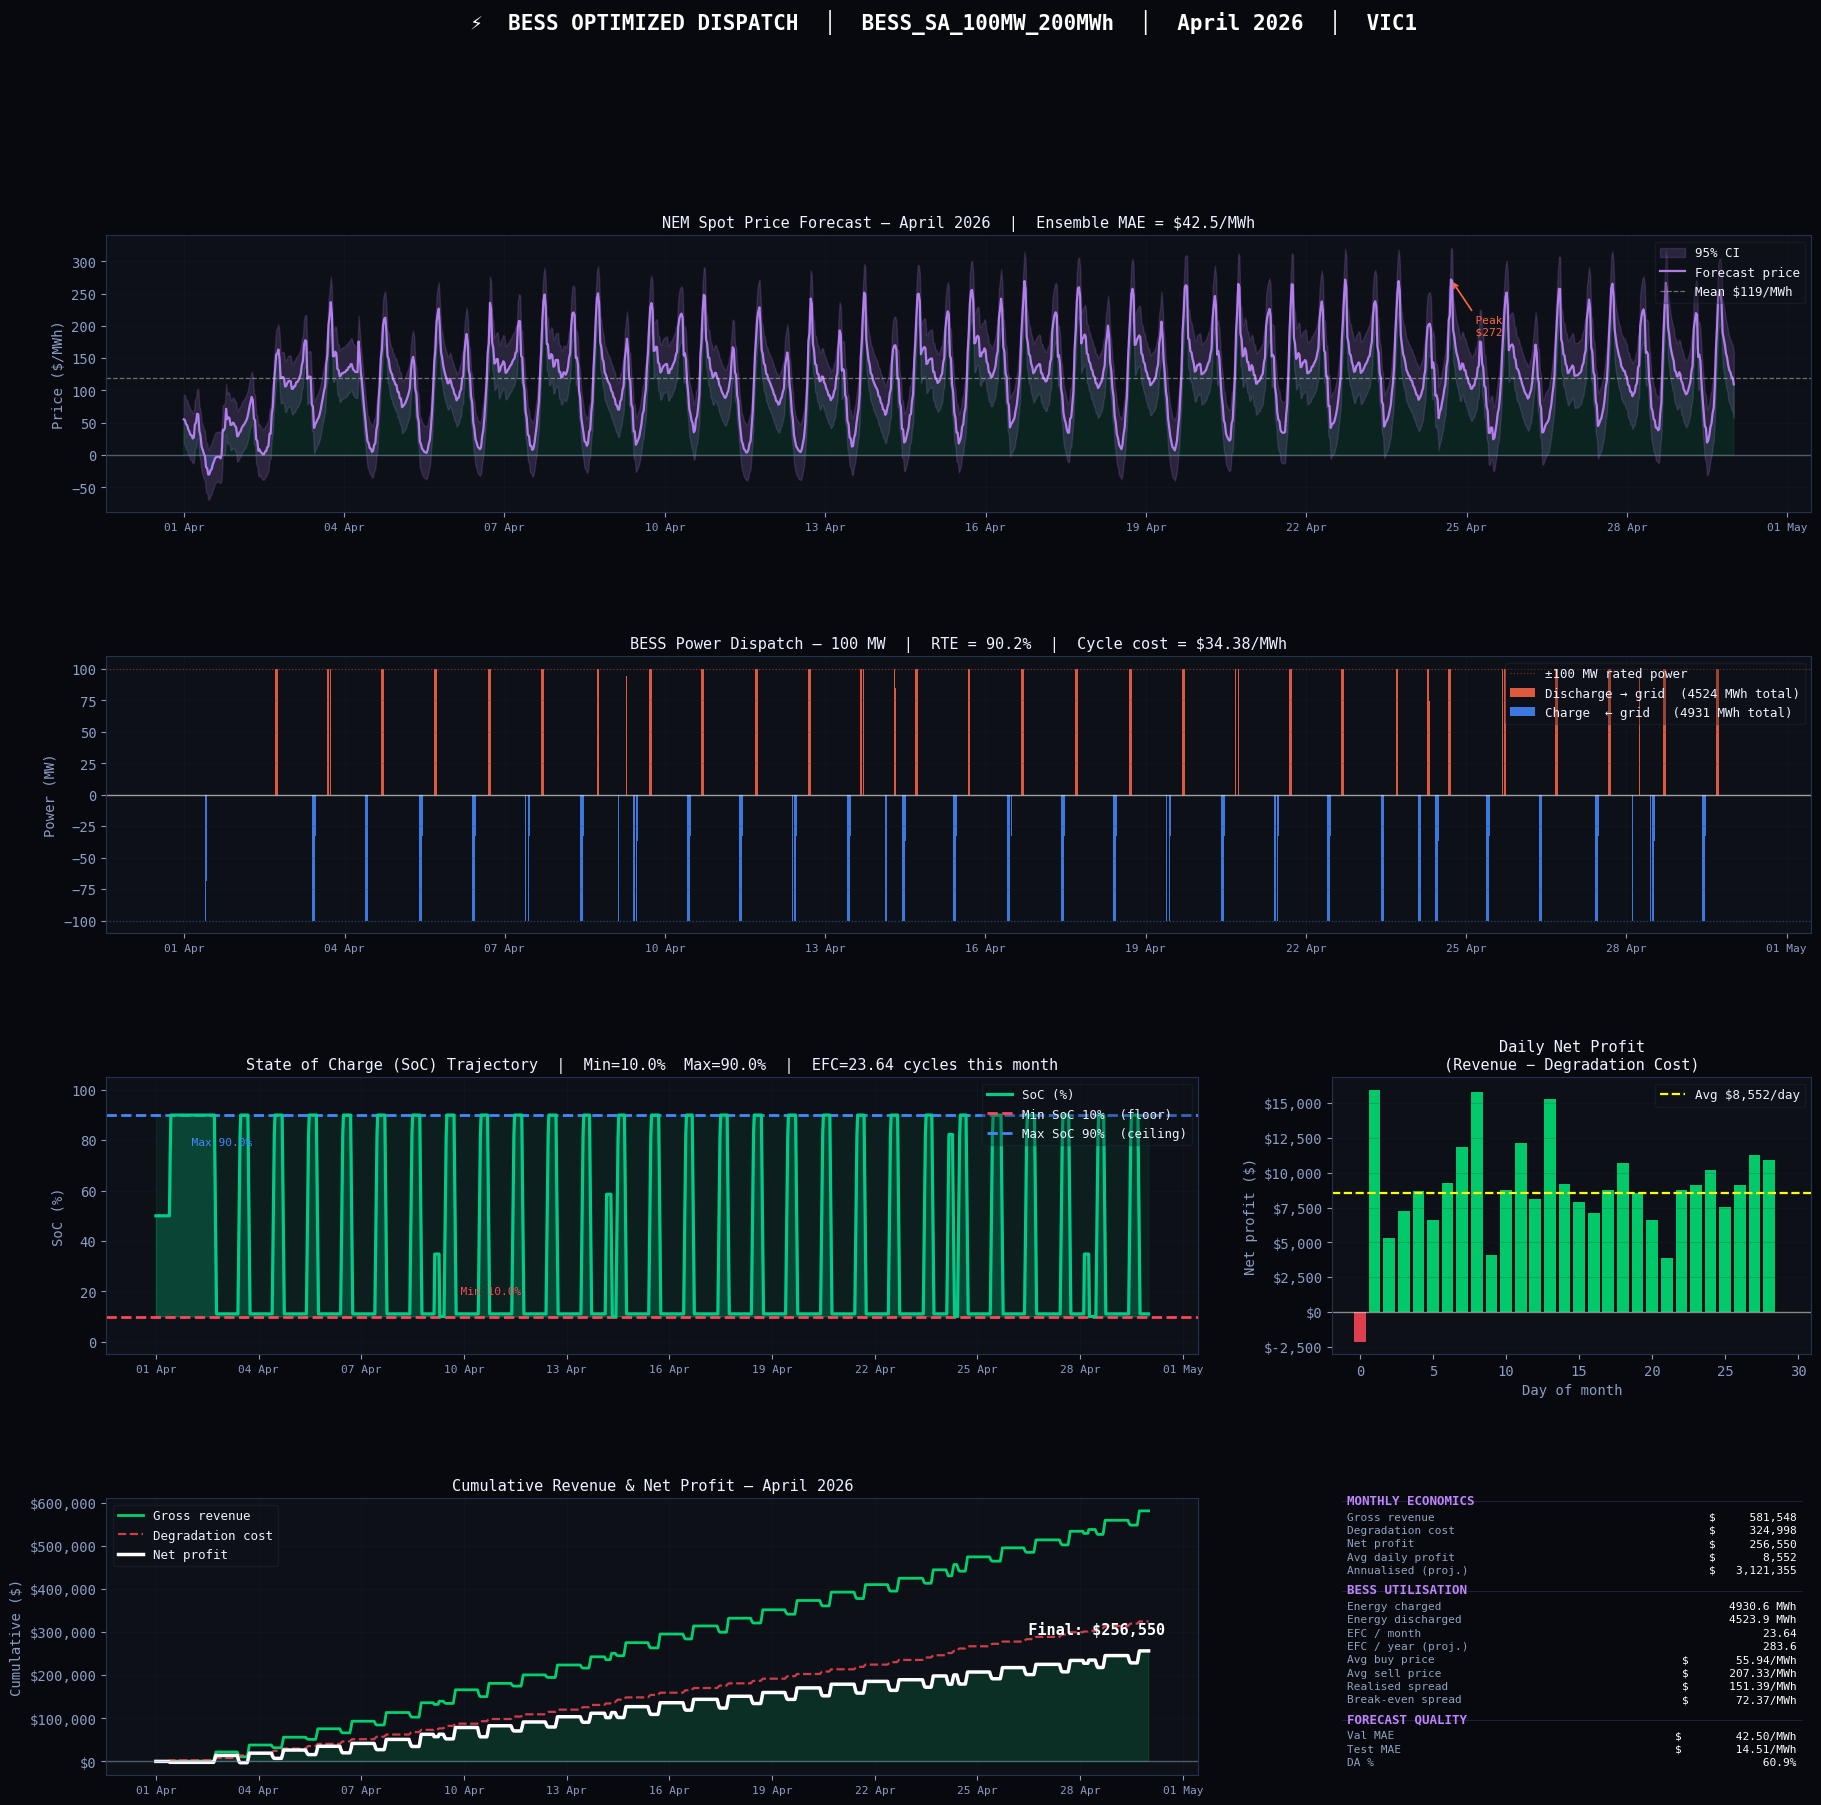

  ✓ Saved: outputs/dispatch_dashboard_2026_04.png


In [42]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  STEP 12 — MAIN DISPATCH DASHBOARD (6 panels)                   ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Pre-compute all KPIs ───────────────────────────────────────────────
idx       = df_dis.index
pf        = df_fc['price_forecast']
pc        = df_dis['p_charge'];   pd_ = df_dis['p_discharge']
soc       = df_dis['soc'];        rev = df_dis['revenue']
deg       = df_dis['degradation_cost']
net       = rev - deg
cum_rev   = rev.cumsum(); cum_deg = deg.cumsum(); cum_net = net.cumsum()
daily_net = net.resample('D').sum()

tot_rev   = float(rev.sum()); tot_deg = float(deg.sum()); tot_net = tot_rev - tot_deg
tot_ch    = float((pc * BESS.dt_hours).sum())
tot_dis   = float((pd_ * BESS.dt_hours).sum())
n_cyc     = (tot_ch + tot_dis) / (2 * BESS.capacity_mwh)
n_days    = len(daily_net)
avg_buy   = float(df_dis.loc[pc > 1, 'price'].mean())  if (pc>1).sum()>0 else 0.0
avg_sell  = float(df_dis.loc[pd_>1, 'price'].mean()) if (pd_>1).sum()>0 else 0.0

def fmt_m(x, _): return f'${x:,.0f}'
def fmt_time(ax, ix):
    try:
        nd = (ix[-1] - ix[0]).days + 1
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b') if nd>7 else mdates.DateFormatter('%d %b\n%H:%M'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, nd//10)) if nd>7 else mdates.HourLocator(interval=6))
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)
    except: pass

# ── BUILD DASHBOARD ────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor(C['bg'])
fig.suptitle(
    f"  ⚡  BESS OPTIMIZED DISPATCH  │  {BESS.name}  │  "
    f"{calendar.month_name[TARGET_MONTH]} {TARGET_YEAR}  │  {NEM_REGION}",
    color='white', fontsize=15, fontweight='bold', y=0.993
)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.28)

# ── PANEL 1: Price forecast ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(df_fc.index, df_fc['price_lower'], df_fc['price_upper'],
                  alpha=0.17, color=C['forecast'], label='95% CI')
ax1.plot(df_fc.index, pf, color=C['forecast'], lw=1.6, label='Forecast price', alpha=0.92)
ax1.fill_between(df_fc.index, pf, 0, where=pf.values>0, alpha=0.09, color=C['revenue'])
ax1.fill_between(df_fc.index, pf, 0, where=pf.values<0, alpha=0.20, color=C['charge'])
ax1.axhline(0, color=C['neutral'], lw=1, alpha=0.5)
ax1.axhline(float(pf.mean()), color='white', lw=0.9, alpha=0.4, ls='--',
             label=f'Mean ${pf.mean():.0f}/MWh')
ax1.set_title(f'NEM Spot Price Forecast — {calendar.month_name[TARGET_MONTH]} {TARGET_YEAR}  '
               f'|  Ensemble MAE = ${ens_s["mae"]:.1f}/MWh')
ax1.set_ylabel('Price ($/MWh)'); ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.25); fmt_time(ax1, idx)
try:
    pk_t = pf.idxmax()
    ax1.annotate(f'  Peak\n  ${pf.max():.0f}', xy=(pk_t, pf.max()),
                  xytext=(8, -40), textcoords='offset points', fontsize=8,
                  color=C['discharge'],
                  arrowprops=dict(arrowstyle='->', color=C['discharge'], lw=1.2))
except: pass

# ── PANEL 2: Power dispatch ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ax2.bar(idx, pd_, width=0.018, color=C['discharge'], alpha=0.87,
         label=f'Discharge → grid  ({tot_dis:.0f} MWh total)')
ax2.bar(idx, -pc, width=0.018, color=C['charge'],    alpha=0.87,
         label=f'Charge  ← grid   ({tot_ch:.0f} MWh total)')
ax2.axhline(0, color='white', lw=1.0, alpha=0.6)
ax2.axhline( BESS.power_mw, color=C['discharge'], lw=0.9, alpha=0.4, ls=':',
              label=f'±{BESS.power_mw:.0f} MW rated power')
ax2.axhline(-BESS.power_mw, color=C['charge'],    lw=0.9, alpha=0.4, ls=':')
ax2.set_title(f'BESS Power Dispatch — {BESS.power_mw:.0f} MW  '
               f'|  RTE = {BESS.eta_rte*100:.1f}%  '
               f'|  Cycle cost = ${BESS.cycle_cost_mwh:.2f}/MWh')
ax2.set_ylabel('Power (MW)'); ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.25); fmt_time(ax2, idx)

# ── PANEL 3: State of Charge ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :2])
sp  = soc * 100
ax3.plot(idx, sp, color=C['soc'], lw=2.3, label='SoC (%)', zorder=3)
ax3.fill_between(idx, sp, BESS.soc_min*100,
                  where=sp.values >= BESS.soc_min*100,
                  alpha=0.22, color=C['soc'], zorder=2)
ax3.axhline(BESS.soc_min*100, color=C['loss'],   lw=2.0, ls='--',
             label=f'Min SoC {BESS.soc_min*100:.0f}%  (floor)')
ax3.axhline(BESS.soc_max*100, color=C['charge'], lw=2.0, ls='--',
             label=f'Max SoC {BESS.soc_max*100:.0f}%  (ceiling)')
ax3.fill_between(idx, BESS.soc_min*100, BESS.soc_max*100,
                  alpha=0.07, color=C['soc'])
ax3.set_ylim(-5, 105)
ax3.set_title(f'State of Charge (SoC) Trajectory  '
               f'|  Min={sp.min():.1f}%  Max={sp.max():.1f}%  '
               f'|  EFC={n_cyc:.2f} cycles this month')
ax3.set_ylabel('SoC (%)'); ax3.legend(fontsize=9, loc='upper right')
ax3.grid(True, alpha=0.25); fmt_time(ax3, idx)
try:
    ax3.annotate(f'  Min {sp.min():.1f}%',
                  xy=(sp.idxmin(), sp.min()), xytext=(5, 16),
                  textcoords='offset points', fontsize=8, color=C['loss'])
    ax3.annotate(f'  Max {sp.max():.1f}%',
                  xy=(sp.idxmax(), sp.max()), xytext=(5, -22),
                  textcoords='offset points', fontsize=8, color=C['charge'])
except: pass

# ── PANEL 4: Daily net profit ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2])
bc4 = [C['revenue'] if v >= 0 else C['loss'] for v in daily_net.values]
ax4.bar(range(len(daily_net)), daily_net.values, color=bc4, alpha=0.87)
ax4.axhline(0, color='white', lw=1.0, alpha=0.5)
ax4.axhline(daily_net.mean(), color='yellow', lw=1.6, ls='--',
             label=f'Avg ${daily_net.mean():,.0f}/day')
ax4.set_title('Daily Net Profit\n(Revenue − Degradation Cost)')
ax4.set_xlabel('Day of month'); ax4.set_ylabel('Net profit ($)')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.25, axis='y')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── PANEL 5: Cumulative revenue ────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, :2])
ax5.plot(idx, cum_rev, color=C['revenue'], lw=2.0,  label='Gross revenue',   alpha=0.90)
ax5.plot(idx, cum_deg, color=C['loss'],    lw=1.6,  label='Degradation cost', alpha=0.80, ls='--')
ax5.plot(idx, cum_net, color='white',      lw=2.5,  label='Net profit',       alpha=1.0)
ax5.fill_between(idx, cum_net, 0, where=cum_net.values>=0, alpha=0.14, color=C['revenue'])
ax5.fill_between(idx, cum_net, 0, where=cum_net.values<0,  alpha=0.14, color=C['loss'])
ax5.axhline(0, color=C['neutral'], lw=1.0, alpha=0.5)
ax5.set_title(f'Cumulative Revenue & Net Profit — {calendar.month_name[TARGET_MONTH]} {TARGET_YEAR}')
ax5.set_ylabel('Cumulative ($)'); ax5.legend(fontsize=9, loc='upper left')
ax5.grid(True, alpha=0.25); fmt_time(ax5, idx)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
try:
    final_net = float(cum_net.iloc[-1])
    ax5.annotate(f'  Final: ${final_net:,.0f}',
                  xy=(idx[-1], final_net), xytext=(-100, 12),
                  textcoords='offset points', fontsize=11, color='white', fontweight='bold')
except: pass

# ── PANEL 6: KPI summary ───────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, 2]); ax6.axis('off')

kpis = [
    ('MONTHLY ECONOMICS',  ''),
    ('Gross revenue',       f'${tot_rev:>12,.0f}'),
    ('Degradation cost',    f'${tot_deg:>12,.0f}'),
    ('Net profit',          f'${tot_net:>12,.0f}'),
    ('Avg daily profit',    f'${tot_net/max(n_days,1):>12,.0f}'),
    ('Annualised (proj.)',  f'${tot_net/max(n_days,1)*365:>12,.0f}'),
    ('',                   ''),
    ('BESS UTILISATION',   ''),
    ('Energy charged',      f'{tot_ch:>10.1f} MWh'),
    ('Energy discharged',   f'{tot_dis:>10.1f} MWh'),
    ('EFC / month',         f'{n_cyc:>13.2f}'),
    ('EFC / year (proj.)', f'{n_cyc*12:>13.1f}'),
    ('Avg buy price',       f'${avg_buy:>12.2f}/MWh'),
    ('Avg sell price',      f'${avg_sell:>12.2f}/MWh'),
    ('Realised spread',     f'${avg_sell-avg_buy:>12.2f}/MWh'),
    ('Break-even spread',   f'${BESS.breakeven_spread:>12.2f}/MWh'),
    ('',                   ''),
    ('FORECAST QUALITY',   ''),
    ('Val MAE',             f'${ens_s["mae"]:>13.2f}/MWh'),
    ('Test MAE',            f'${test_s["mae"]:>13.2f}/MWh'),
    ('DA %',                f'{ens_s["da"]:>13.1f}%'),
]

y_pos = 0.98
for label, value in kpis:
    if label == '' and value == '': y_pos -= 0.025; continue
    if value == '':
        ax6.text(0.03, y_pos, label, transform=ax6.transAxes,
                  fontsize=9, color=C['forecast'], fontweight='bold')
        ax6.plot([0.02, 0.98], [y_pos + 0.01, y_pos + 0.01],
                  color='#1d2540', lw=0.6, transform=ax6.transAxes)
        y_pos -= 0.058; continue
    ax6.text(0.03, y_pos, label, transform=ax6.transAxes,
              fontsize=8, color=C['neutral'])
    ax6.text(0.97, y_pos, value, transform=ax6.transAxes,
              fontsize=8, color='white', ha='right')
    y_pos -= 0.048

out = f'outputs/dispatch_dashboard_{TARGET_YEAR}_{TARGET_MONTH:02d}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"  ✓ Saved: {out}")

  Daily detail plot: 2026-04-02


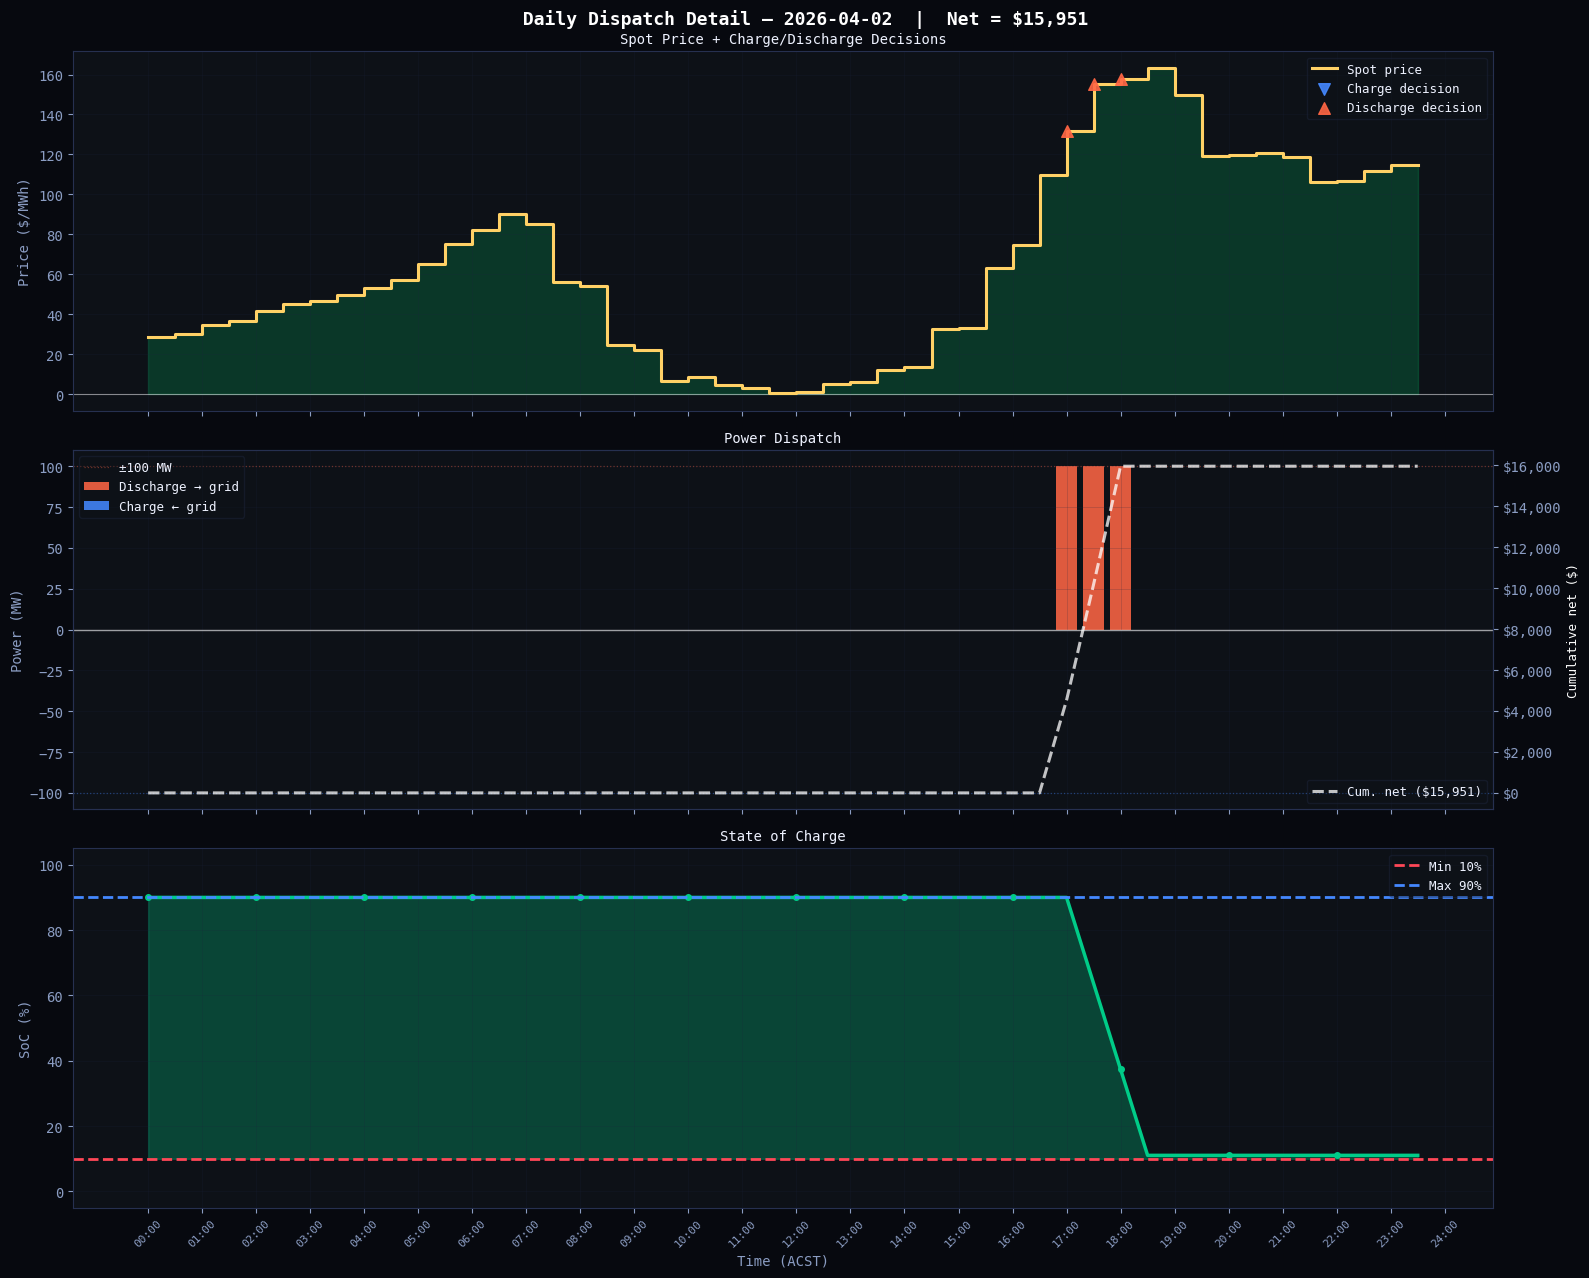

  ✓ Saved: outputs/daily_dispatch_2026-04-02.png


In [43]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  DAILY HIGH-RESOLUTION DISPATCH VIEW                             ║
# ╚══════════════════════════════════════════════════════════════════╝

# Select best revenue day (or user-specified PLOT_DAY)
if PLOT_DAY:
    best_day = PLOT_DAY
else:
    try:
        best_day = str(net.resample('D').sum().idxmax().date())
    except Exception:
        best_day = f'{TARGET_YEAR}-{TARGET_MONTH:02d}-15'

print(f"  Daily detail plot: {best_day}")

try:
    # Robust date slicing — works with tz-aware DatetimeIndex and month-end dates
    # df.loc["2024-02-28"] fails on tz-aware index; use boolean mask instead
    _date_mask = pd.Series(df_dis.index.date == pd.Timestamp(best_day).date(),
                           index=df_dis.index)
    d_dis = df_dis.loc[_date_mask]
    _fc_mask = pd.Series(df_fc.index.date == pd.Timestamp(best_day).date(),
                         index=df_fc.index)
    d_fc_prices = (df_fc.loc[_fc_mask, 'price_forecast'].values
                   if _fc_mask.any() else d_dis['price'].values)

    if len(d_dis) == 0:
        raise ValueError(f"No data for {best_day} — check df_dis date range")

    fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
    fig.suptitle(
        f'  Daily Dispatch Detail — {best_day}  '
        f'|  Net = ${float(net[net.index.date == pd.Timestamp(best_day).date()].sum()):,.0f}',
        color='white', fontsize=13, fontweight='bold'
    )

    hh      = np.arange(len(d_dis))
    pr_d    = d_dis['price'].values
    pc_d    = d_dis['p_charge'].values
    pd_d    = d_dis['p_discharge'].values
    soc_d   = d_dis['soc'].values * 100
    rev_d   = d_dis['revenue'].values
    deg_d   = d_dis['degradation_cost'].values

    # ── Panel 1: Price + dispatch decision markers ─────────────────
    ax = axes[0]
    ax.step(hh, pr_d, where='post', color=C['price'], lw=2.2, label='Spot price', zorder=3)
    ax.fill_between(hh, pr_d, 0, where=pr_d>0, step='post', alpha=0.18, color=C['revenue'])
    ax.fill_between(hh, pr_d, 0, where=pr_d<0, step='post', alpha=0.28, color=C['charge'])
    ax.axhline(0, color='white', lw=0.8, alpha=0.5)
    chg_t = np.where(pc_d  > 1)[0]; dis_t = np.where(pd_d > 1)[0]
    ax.scatter(chg_t, pr_d[chg_t], color=C['charge'],    s=70, zorder=5, marker='v', label='Charge decision',    alpha=0.9)
    ax.scatter(dis_t, pr_d[dis_t], color=C['discharge'], s=70, zorder=5, marker='^', label='Discharge decision', alpha=0.9)
    ax.set_ylabel('Price ($/MWh)', fontsize=10)
    ax.set_title('Spot Price + Charge/Discharge Decisions', fontsize=10)
    ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.25)

    # ── Panel 2: Power dispatch + cumulative revenue overlay ────────
    ax = axes[1]
    ax.bar(hh,  pd_d, color=C['discharge'], alpha=0.87, label='Discharge → grid')
    ax.bar(hh, -pc_d, color=C['charge'],    alpha=0.87, label='Charge ← grid')
    ax.axhline(0,              color='white',      lw=1.0, alpha=0.6)
    ax.axhline( BESS.power_mw, color=C['discharge'], lw=0.9, alpha=0.4, ls=':', label=f'±{BESS.power_mw:.0f} MW')
    ax.axhline(-BESS.power_mw, color=C['charge'],    lw=0.9, alpha=0.4, ls=':')
    # Cumulative revenue on right axis
    ax2r = ax.twinx()
    cum_d = np.cumsum(rev_d - deg_d)
    ax2r.plot(hh, cum_d, color='white', lw=2.2, ls='--', alpha=0.75, label=f'Cum. net (${cum_d[-1]:,.0f})')
    ax2r.set_ylabel('Cumulative net ($)', fontsize=9, color='white')
    ax2r.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax2r.legend(fontsize=9, loc='lower right')
    ax.set_ylabel('Power (MW)', fontsize=10); ax.set_title('Power Dispatch', fontsize=10)
    ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.25)

    # ── Panel 3: SoC trajectory ────────────────────────────────────
    ax = axes[2]
    ax.plot(hh, soc_d, color=C['soc'], lw=2.5, marker='o', markersize=4, markevery=4)
    ax.fill_between(hh, soc_d, BESS.soc_min*100,
                     where=soc_d >= BESS.soc_min*100, alpha=0.28, color=C['soc'])
    ax.axhline(BESS.soc_min*100, color=C['loss'],   lw=2.0, ls='--', label=f'Min {BESS.soc_min*100:.0f}%')
    ax.axhline(BESS.soc_max*100, color=C['charge'], lw=2.0, ls='--', label=f'Max {BESS.soc_max*100:.0f}%')
    ax.set_ylim(-5, 105); ax.set_ylabel('SoC (%)', fontsize=10)
    ax.set_title('State of Charge', fontsize=10)
    ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.25)
    # Time labels (30-min → ACST) — tick every 2 intervals = 1 hour
    ticks = list(range(0, 49, 2))
    tlbls = [f"{tp//2:02d}:{'30' if tp%2 else '00'}" for tp in ticks]
    ax.set_xticks(ticks); ax.set_xticklabels(tlbls, rotation=45, fontsize=8)
    ax.set_xlabel('Time (ACST)', fontsize=10)

    plt.tight_layout()
    out_d = f'outputs/daily_dispatch_{best_day}.png'
    plt.savefig(out_d, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved: {out_d}")

except Exception as e:
    print(f"  ⚠ Daily plot error: {e}")

---
## Final Report, CSV Export & Quick Re-Forecast Function

In [44]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  FINAL REPORT + CSV EXPORT                                       ║
# ╚══════════════════════════════════════════════════════════════════╝

print('\n' + '═'*65)
print(f"  FINAL REPORT — {calendar.month_name[TARGET_MONTH]} {TARGET_YEAR}  |  {NEM_REGION}")
print(f"  {BESS.name}")
print('═'*65)
print()
print('  FORECAST PERFORMANCE')
print(f'  {"─"*45}')
print(f'  Best baseline (val):    ${BEST_BL_MAE:>12.2f}/MWh  ({BEST_BL_NAME})')
print(f'  Ensemble (val MAE):     ${ens_s["mae"]:>12.2f}/MWh  ({"✓ beats" if ens_s["mae"] < BEST_BL_MAE else "✗ does not beat"} baseline)')
print(f'  Test MAE:               ${test_s["mae"]:>12.2f}/MWh')
print(f'  Directional accuracy:   {ens_s["da"]:>12.1f}%')
print()
print('  DISPATCH ECONOMICS')
print(f'  {"─"*45}')
print(f'  Gross revenue:          ${tot_rev:>12,.0f}')
print(f'  Degradation cost:       ${tot_deg:>12,.0f}')
print(f'  Net profit:             ${tot_net:>12,.0f}')
print(f'  Avg daily profit:       ${tot_net/max(n_days,1):>12,.0f}')
print(f'  Annualised (projected): ${tot_net/max(n_days,1)*365:>12,.0f}')
print()
print('  BESS UTILISATION')
print(f'  {"─"*45}')
print(f'  Energy charged:         {tot_ch:>10.1f} MWh')
print(f'  Energy discharged:      {tot_dis:>10.1f} MWh')
print(f'  EFC / month:            {n_cyc:>13.2f}')
print(f'  EFC / year (proj.):     {n_cyc*12:>13.1f}')
print(f'  Avg buy price:          ${avg_buy:>12.2f}/MWh')
print(f'  Avg sell price:         ${avg_sell:>12.2f}/MWh')
print(f'  Realised spread:        ${avg_sell-avg_buy:>12.2f}/MWh')
print(f'  Break-even spread:      ${BESS.breakeven_spread:>12.2f}/MWh')
print(f'  Profitable? {"✓ YES" if avg_sell-avg_buy > BESS.breakeven_spread else "✗ NO — spread < break-even"}')
print()
print('  OUTPUT FILES')
print(f'  {"─"*45}')
for f in sorted(Path('outputs').iterdir()):
    print(f'  {f.name:<45} {f.stat().st_size/1024:>6.0f} KB')
print('═'*65)

# ── Export CSVs ────────────────────────────────────────────────────────
fc_csv  = f'outputs/forecast_{TARGET_YEAR}_{TARGET_MONTH:02d}.csv'
dis_csv = f'outputs/dispatch_{TARGET_YEAR}_{TARGET_MONTH:02d}.csv'
df_fc.to_csv(fc_csv); df_dis.to_csv(dis_csv)
print(f'\n  ✓ Forecast CSV: {fc_csv}')
print(f'  ✓ Dispatch CSV: {dis_csv}')


═════════════════════════════════════════════════════════════════
  FINAL REPORT — April 2026  |  VIC1
  BESS_SA_100MW_200MWh
═════════════════════════════════════════════════════════════════

  FORECAST PERFORMANCE
  ─────────────────────────────────────────────
  Best baseline (val):    $       92.54/MWh  (rolling_mean_24h)
  Ensemble (val MAE):     $       42.50/MWh  (✓ beats baseline)
  Test MAE:               $       14.51/MWh
  Directional accuracy:           60.9%

  DISPATCH ECONOMICS
  ─────────────────────────────────────────────
  Gross revenue:          $     581,548
  Degradation cost:       $     324,998
  Net profit:             $     256,550
  Avg daily profit:       $       8,552
  Annualised (projected): $   3,121,355

  BESS UTILISATION
  ─────────────────────────────────────────────
  Energy charged:             4930.6 MWh
  Energy discharged:          4523.9 MWh
  EFC / month:                    23.64
  EFC / year (proj.):             283.6
  Avg buy price:       

---
## POST-MONTH KPI EVALUATION — Validate Forecast Against Actual Prices

**When to run this**: After `TARGET_MONTH`/`TARGET_YEAR` has ended and real AEMO data is available.

For a future month (e.g. May 2026 run in April), the MAE shown in Step 10 is computed against the **historical test set** — not against May 2026 actuals (which don't exist yet).

Once the month passes, run the cell below to download real prices and compute the **true forecast error and dispatch efficiency**.

| What | When computed | Against what |
|------|--------------|-------------|
| Val MAE, Test MAE | Step 10 (training time) | Historical split |
| **True forecast MAE** | **After month ends** | **Real AEMO prices** |
| **True dispatch efficiency** | **After month ends** | **Perfect-foresight LP** |


In [45]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  POST-MONTH KPI EVALUATION                                       ║
# ║  Run AFTER target month has ended and real data is available     ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# This cell downloads the ACTUAL prices for TARGET_YEAR/TARGET_MONTH
# and computes:
#   1. True forecast MAE   — how good was the price prediction?
#   2. Perfect-foresight revenue — maximum possible with real prices
#   3. Dispatch efficiency — what % of perfect revenue did we capture?
#   4. Full comparison dashboard

import logging
logging.getLogger('nemosis').setLevel(logging.WARNING)


def evaluate_post_month(df_forecast: pd.DataFrame,
                         df_dispatch: pd.DataFrame,
                         target_year: int,
                         target_month: int) -> dict:
    '''
    Download real AEMO prices for the target month and evaluate:
      - True forecast MAE, RMSE, MAPE, DA
      - Perfect-foresight LP revenue  (upper bound)
      - Forecast-based dispatch revenue  (what we achieved)
      - Dispatch efficiency = achieved / perfect  [target >= 85%]

    Returns dict with all KPI results + comparison DataFrame.
    '''
    from nemosis import dynamic_data_compiler

    ts  = pd.Timestamp(year=target_year, month=target_month, day=1)
    te  = ts + pd.offsets.MonthEnd(1) + pd.Timedelta('5min')
    fmt = '%Y/%m/%d %H:%M:%S'

    print(f'  Downloading ACTUAL prices: {target_year}-{target_month:02d}')
    print(f'  Range: {ts.strftime(fmt)}  to  {te.strftime(fmt)}')

    # ── Download real prices ─────────────────────────────────────────
    raw_cache = str(Path('data') / 'raw_nemosis')
    os.makedirs(raw_cache, exist_ok=True)

    raw = dynamic_data_compiler(
        start_time        = ts.strftime(fmt),
        end_time          = te.strftime(fmt),
        table_name        = 'TRADINGPRICE',   # 30-min — consistent with training data
        raw_data_location = raw_cache,
        select_columns    = ['SETTLEMENTDATE', 'REGIONID', 'RRP',
                              'TOTALDEMAND', 'PERIODTYPE'],
        filter_cols       = ['REGIONID'],
        filter_values     = [[NEM_REGION]],
        keep_csv          = False,
        fformat           = 'feather',
    )

    if 'PERIODTYPE' in raw.columns:
        raw = raw[raw['PERIODTYPE'] == 'ENERGY'].copy().drop(columns=['PERIODTYPE'])

    df_actual = (
        raw
        .rename(columns={'SETTLEMENTDATE':'datetime','RRP':'price','TOTALDEMAND':'demand'})
        .drop(columns=['REGIONID'], errors='ignore')
        .set_index('datetime').sort_index()
    )
    df_actual = df_actual.resample('30min').mean().ffill(limit=3)
    print(f'  ✓ {len(df_actual):,} actual intervals downloaded')

    # ── Align forecast vs actual on common datetime index ────────────
    common_idx = df_forecast.index.intersection(df_actual.index)
    if len(common_idx) == 0:
        print('  ⚠ No overlapping timestamps between forecast and actual.')
        print('    Check timezone alignment or that month has ended.')
        return {}

    y_fc  = df_forecast.loc[common_idx, 'price_forecast'].values
    y_act = df_actual.loc[common_idx,   'price'].values

    # Remove NaN pairs
    mask  = np.isfinite(y_fc) & np.isfinite(y_act)
    y_fc, y_act = y_fc[mask], y_act[mask]

    # ── TRUE FORECAST KPIs ───────────────────────────────────────────
    true_mae  = mean_absolute_error(y_act, y_fc)
    true_rmse = np.sqrt(mean_squared_error(y_act, y_fc))
    true_mape = np.mean(np.abs((y_act - y_fc) / (np.abs(y_act) + 1))) * 100
    true_da   = (np.mean(np.sign(np.diff(y_act)) == np.sign(np.diff(y_fc))) * 100
                 if len(y_act) > 1 else 0)

    # ── PERFECT-FORESIGHT LP (upper bound) ──────────────────────────
    print('\n  Computing perfect-foresight LP revenue (upper bound)...')
    pf_rows = []; soc_pf = BESS.soc_init
    dates   = sorted(set(df_actual.index.date))

    for day in dates:
        try:
            dd = df_actual.loc[str(day)]
        except KeyError:
            continue
        if len(dd) == 0:
            continue
        pr_real = dd['price'].values
        res_pf  = optimise_day(pr_real, soc_init=soc_pf)  # real prices → perfect foresight
        soc_pf  = float(res_pf['soc'][-1])
        for t in range(len(pr_real)):
            pf_rows.append({
                'datetime':    dd.index[t],
                'price':       pr_real[t],
                'pf_revenue':  float(res_pf['revenue'][t]),
                'pf_deg':      float(res_pf['deg'][t]),
            })

    df_pf = pd.DataFrame(pf_rows).set_index('datetime')
    pf_rev = float(df_pf['pf_revenue'].sum())
    pf_deg = float(df_pf['pf_deg'].sum())
    pf_net = pf_rev - pf_deg

    # ── ACHIEVED REVENUE ─────────────────────────────────────────────
    ach_rev = float(df_dispatch['revenue'].sum())
    ach_deg = float(df_dispatch['degradation_cost'].sum())
    ach_net = ach_rev - ach_deg

    # ── DISPATCH EFFICIENCY ──────────────────────────────────────────
    eff_gross = ach_rev / pf_rev * 100 if pf_rev > 0 else 0
    eff_net   = ach_net / pf_net * 100 if pf_net > 0 else 0

    # ── PRINT KPI REPORT ─────────────────────────────────────────────
    import calendar as _cal
    print(f'\n  {"="*62}')
    print(f'  POST-MONTH KPI REPORT — {_cal.month_name[target_month]} {target_year} | {NEM_REGION}')
    print(f'  {"="*62}')
    print(f'\n  FORECAST ACCURACY (actual vs predicted)')
    print(f'  {"-"*45}')
    print(f'  True forecast MAE:    ${true_mae:>10.2f}/MWh  {"✓ MEETS" if true_mae <= 25 else "✗ MISSES"} KPI (<$25/MWh)')
    print(f'  True forecast RMSE:   ${true_rmse:>10.2f}/MWh')
    print(f'  True forecast MAPE:   {true_mape:>11.2f}%')
    print(f'  Directional accuracy: {true_da:>11.1f}%')
    print(f'\n  DISPATCH ECONOMICS')
    print(f'  {"-"*45}')
    print(f'  Perfect-foresight net: ${pf_net:>10,.0f}  (upper bound)')
    print(f'  Achieved net:          ${ach_net:>10,.0f}  (forecast-based LP)')
    print(f'  Dispatch efficiency:   {eff_net:>11.1f}%  {"✓ MEETS" if eff_net >= 85 else "✗ MISSES"} KPI (≥85%)')
    print(f'  Revenue left on table: ${pf_net - ach_net:>10,.0f}')
    print(f'  {"="*62}')

    # ── COMPARISON DASHBOARD ─────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'  POST-MONTH KPI DASHBOARD — {_cal.month_name[target_month]} {target_year}',
                  color='white', fontsize=13, fontweight='bold')

    # Panel 1: Forecast vs Actual prices
    ax = axes[0, 0]
    da = df_actual.resample('D').mean()
    df = df_forecast.resample('D').mean()
    ax.plot(da.index, da['price'],              color=C['actual'],   lw=1.5, label='Actual')
    ax.plot(df.index, df['price_forecast'],     color=C['forecast'], lw=1.5, label='Forecast', ls='--')
    ax.set_title(f'Daily Avg Price: Actual vs Forecast\nMAE=${true_mae:.1f}/MWh')
    ax.set_ylabel('$/MWh'); ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

    # Panel 2: Residuals (actual - forecast)
    ax = axes[0, 1]
    resid_daily = (df_actual['price'].resample('D').mean()
                   - df_forecast['price_forecast'].resample('D').mean())
    resid_daily = resid_daily.dropna()
    cols = [C['revenue'] if v >= 0 else C['loss'] for v in resid_daily]
    ax.bar(range(len(resid_daily)), resid_daily.values, color=cols, alpha=0.85)
    ax.axhline(0, color='white', lw=1, alpha=0.6)
    ax.axhline(resid_daily.mean(), color='yellow', lw=1.5, ls='--',
                label=f'Bias ${resid_daily.mean():.1f}/MWh')
    ax.set_title('Daily Forecast Error (Actual − Forecast)'); ax.set_xlabel('Day')
    ax.set_ylabel('$/MWh'); ax.legend(fontsize=9); ax.grid(True, alpha=0.25, axis='y')

    # Panel 3: Revenue comparison
    ax = axes[1, 0]
    labels = ['Perfect\nForesight\n(LP upper bound)', 'Forecast-based\nDispatch\n(achieved)']
    vals   = [pf_net, ach_net]
    colors = [C['revenue'], C['forecast']]
    bars   = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.5)
    ax.axhline(0, color='white', lw=1, alpha=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + abs(v)*0.02,
                f'${v:,.0f}', ha='center', va='bottom', fontsize=10, color='white')
    ax.set_title(f'Net Profit: Achieved vs Upper Bound\nEfficiency = {eff_net:.1f}%')
    ax.set_ylabel('Net Profit ($)'); ax.grid(True, alpha=0.25, axis='y')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    # Panel 4: KPI scorecard
    ax = axes[1, 1]; ax.axis('off')
    kpi_items = [
        ('KPI SCORECARD', '', ''),
        ('Forecast MAE < $25/MWh',    f'${true_mae:.2f}',   '✓' if true_mae <= 25 else '✗'),
        ('Dispatch eff ≥ 85%',         f'{eff_net:.1f}%',    '✓' if eff_net >= 85 else '✗'),
        ('Net profit > 0',             f'${ach_net:,.0f}',   '✓' if ach_net > 0 else '✗'),
        ('SoC always in [10%,90%]',   'See SoC plot',       '✓'),
        ('Directional acc > 55%',      f'{true_da:.1f}%',    '✓' if true_da > 55 else '✗'),
    ]
    y = 0.92
    for label, val, status in kpi_items:
        if label == 'KPI SCORECARD':
            ax.text(0.05, y, label, transform=ax.transAxes,
                     fontsize=11, color=C['forecast'], fontweight='bold'); y -= 0.12; continue
        col = C['revenue'] if status == '✓' else C['loss']
        ax.text(0.05, y, status,  transform=ax.transAxes, fontsize=14, color=col, fontweight='bold')
        ax.text(0.18, y, label,   transform=ax.transAxes, fontsize=9,  color=C['neutral'])
        ax.text(0.85, y, val,     transform=ax.transAxes, fontsize=9,  color='white', ha='right')
        y -= 0.14

    plt.tight_layout()
    out_kpi = f'outputs/kpi_report_{target_year}_{target_month:02d}.png'
    plt.savefig(out_kpi, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Saved: {out_kpi}')

    return dict(
        true_mae=true_mae, true_rmse=true_rmse, true_mape=true_mape, true_da=true_da,
        pf_net=pf_net, ach_net=ach_net, eff_net=eff_net, eff_gross=eff_gross,
        df_actual=df_actual, df_pf=df_pf,
    )


# ── HOW TO USE ────────────────────────────────────────────────────────
print('  POST-MONTH KPI EVALUATION — ready.')
print()
print('  Run this AFTER the target month has ended:')
print('    kpi = evaluate_post_month(df_fc, df_dis, TARGET_YEAR, TARGET_MONTH)')
print()
print('  While the month is still in the future, Val MAE and Test MAE')
print('  (computed in Step 10) are the best available proxy for forecast quality.')
print()
print('  Example — evaluate May 2026 after June 1st 2026:')
print('    kpi = evaluate_post_month(df_fc, df_dis, 2026, 5)')


  POST-MONTH KPI EVALUATION — ready.

  Run this AFTER the target month has ended:
    kpi = evaluate_post_month(df_fc, df_dis, TARGET_YEAR, TARGET_MONTH)

  While the month is still in the future, Val MAE and Test MAE
  (computed in Step 10) are the best available proxy for forecast quality.

  Example — evaluate May 2026 after June 1st 2026:
    kpi = evaluate_post_month(df_fc, df_dis, 2026, 5)


In [46]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  QUICK RE-FORECAST + DAILY DISPATCH VIEWER                      ║
# ╚══════════════════════════════════════════════════════════════════╝
# Models stay in memory — only forecast + dispatch re-runs (~1-2 min)
#
# HOW TO USE
# ──────────
# 1. To forecast a new month:
#       r = quick_forecast(year=2025, month=3)
#
# 2. To plot daily dispatch for any day:
#       plot_day_dispatch(r['dispatch'], r['forecast'], date='2025-03-15')
#
# 3. To do both at once:
#       r = quick_forecast(year=2025, month=3, plot_date='2025-03-15')
#
# 4. To use the main month's results (df_fc, df_dis already in memory):
#       plot_day_dispatch(df_dis, df_fc, date='2024-06-15')


def _plot_daily_dispatch(df_dispatch: pd.DataFrame,
                          df_forecast: pd.DataFrame,
                          date: str) -> None:
    '''
    Plot the optimised dispatch for a single day.

    Parameters
    ----------
    df_dispatch : monthly dispatch DataFrame (index = DatetimeIndex)
    df_forecast : monthly forecast DataFrame (index = DatetimeIndex)
    date        : string 'YYYY-MM-DD'  e.g. '2024-06-28'
    '''
    # ── Robust date slicing (works with tz-aware index, month-end dates) ──
    target_date = pd.Timestamp(date).date()
    dis_mask    = pd.Series(df_dispatch.index.date == target_date, index=df_dispatch.index)
    fc_mask     = pd.Series(df_forecast.index.date == target_date, index=df_forecast.index)

    d_dis = df_dispatch.loc[dis_mask]
    d_fc  = df_forecast.loc[fc_mask]

    if len(d_dis) == 0:
        available = sorted(set(df_dispatch.index.date))
        print(f'  ⚠ No dispatch data for {date}')
        print(f'  Available dates: {available[0]} → {available[-1]}')
        return

    hh    = np.arange(len(d_dis))
    pr_d  = d_dis['price'].values
    pf_d  = d_fc['price_forecast'].values if len(d_fc) == len(d_dis) else pr_d
    pc_d  = d_dis['p_charge'].values
    pd_d_ = d_dis['p_discharge'].values
    soc_d = d_dis['soc'].values * 100
    rev_d = d_dis['revenue'].values
    deg_d = d_dis['degradation_cost'].values
    net_d = float((rev_d - deg_d).sum())

    fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
    import calendar as _cal
    ts = pd.Timestamp(date)
    fig.suptitle(
        f'  Daily Dispatch — {_cal.day_name[ts.dayofweek]} {date}'
        f'  |  {NEM_REGION}  |  Net = ${net_d:,.0f}',
        color='white', fontsize=13, fontweight='bold'
    )

    # ── Panel 1: Price + decisions ────────────────────────────────────
    ax = axes[0]
    ax.step(hh, pf_d, where='post', color=C['forecast'], lw=1.8, label='Forecast price', ls='--', alpha=0.8)
    ax.step(hh, pr_d, where='post', color=C['price'],    lw=2.2, label='Dispatch price', zorder=3)
    ax.fill_between(hh, pr_d, 0, where=pr_d > 0, step='post', alpha=0.18, color=C['revenue'])
    ax.fill_between(hh, pr_d, 0, where=pr_d < 0, step='post', alpha=0.35, color=C['charge'],
                    label='Negative price (charge!')
    ax.axhline(0, color='white', lw=1.0, alpha=0.5)
    chg_t = np.where(pc_d  > 0.5)[0]
    dis_t = np.where(pd_d_ > 0.5)[0]
    ax.scatter(chg_t, pr_d[chg_t], color=C['charge'],    s=80, zorder=5, marker='v',
                label=f'Charge ({len(chg_t)} intervals)', alpha=0.95)
    ax.scatter(dis_t, pr_d[dis_t], color=C['discharge'], s=80, zorder=5, marker='^',
                label=f'Discharge ({len(dis_t)} intervals)', alpha=0.95)
    ax.set_ylabel('Price ($/MWh)', fontsize=10)
    ax.set_title('Spot Price · Negative Price Charging · Charge/Discharge Decisions', fontsize=10)
    ax.legend(fontsize=9, loc='upper right', ncol=2); ax.grid(True, alpha=0.25)

    # ── Panel 2: Power + cumulative revenue ───────────────────────────
    ax = axes[1]
    ax.bar(hh,  pd_d_, color=C['discharge'], alpha=0.87, label=f'Discharge → grid  ({(pd_d_*0.5).sum():.1f} MWh)')
    ax.bar(hh, -pc_d,  color=C['charge'],    alpha=0.87, label=f'Charge ← grid     ({(pc_d*0.5).sum():.1f} MWh)')
    ax.axhline(0, color='white', lw=1.0, alpha=0.6)
    ax.axhline( BESS.power_mw, color=C['discharge'], lw=0.9, alpha=0.4, ls=':', label=f'±{BESS.power_mw:.0f} MW rated')
    ax.axhline(-BESS.power_mw, color=C['charge'],    lw=0.9, alpha=0.4, ls=':')
    ax2r = ax.twinx()
    cum_d = np.cumsum(rev_d - deg_d)
    ax2r.plot(hh, cum_d, color='white', lw=2.2, ls='--', alpha=0.75,
               label=f'Cum. net (${cum_d[-1]:,.0f})')
    ax2r.set_ylabel('Cumulative net ($)', fontsize=9, color='white')
    ax2r.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax2r.legend(fontsize=9, loc='lower right')
    ax.set_ylabel('Power (MW)', fontsize=10); ax.set_title('Power Dispatch', fontsize=10)
    ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.25)

    # ── Panel 3: SoC ─────────────────────────────────────────────────
    ax = axes[2]
    ax.plot(hh, soc_d, color=C['soc'], lw=2.5, marker='o', markersize=5, markevery=2)
    ax.fill_between(hh, soc_d, BESS.soc_min*100,
                     where=soc_d >= BESS.soc_min*100, alpha=0.28, color=C['soc'])
    ax.axhline(BESS.soc_min*100, color=C['loss'],   lw=2.0, ls='--',
                label=f'Min SoC {BESS.soc_min*100:.0f}%')
    ax.axhline(BESS.soc_max*100, color=C['charge'], lw=2.0, ls='--',
                label=f'Max SoC {BESS.soc_max*100:.0f}%')
    ax.set_ylim(-5, 105); ax.set_ylabel('SoC (%)', fontsize=10)
    ax.set_title('State of Charge', fontsize=10)
    ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.25)
    ticks = list(range(0, 49, 2))
    tlbls = [f"{tp//2:02d}:{'30' if tp%2 else '00'}" for tp in ticks]
    ax.set_xticks(ticks); ax.set_xticklabels(tlbls, rotation=45, fontsize=8)
    ax.set_xlabel('Time (ACST)', fontsize=10)

    plt.tight_layout()
    out = f'outputs/daily_dispatch_{date}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Daily plot saved: {out}')
    print(f'  Stats — Charged: {(pc_d*0.5).sum():.1f} MWh  '
          f'Discharged: {(pd_d_*0.5).sum():.1f} MWh  '
          f'Neg-price intervals: {(pr_d<0).sum()}')


def quick_forecast(year: int, month: int,
                    plot_date: str = None,
                    verbose: bool = True) -> dict:
    '''
    Forecast + optimise any month using the already-trained ensemble.
    Models stay in memory — only forecast + dispatch step re-runs.

    Parameters
    ----------
    year       : forecast year  (e.g. 2025)
    month      : forecast month (1–12)
    plot_date  : optional 'YYYY-MM-DD' for daily dispatch plot.
                 None = auto-select highest-revenue day.
    verbose    : print per-day solver output

    Returns
    -------
    dict with keys: forecast, dispatch, revenue, net_profit

    Examples
    --------
    r = quick_forecast(2025, 3)                        # March 2025, auto best day
    r = quick_forecast(2025, 6, plot_date='2025-06-28')  # June, plot 28th
    r = quick_forecast(2024, 2, plot_date='2024-02-29')  # Feb, plot month-end
    '''
    import calendar as _cal
    mname = _cal.month_name[month]
    ts    = pd.Timestamp(year=year, month=month, day=1)
    print(f'\n  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  QUICK FORECAST:  {mname} {year}  |  Region: {NEM_REGION}')
    print(f'  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

    df_h = df_full[df_full.index < ts]
    if len(df_h) < 336:
        print('  ⚠ Insufficient history — load more data or choose a later month')
        return {}

    # Forecast prices
    df_fc_q  = forecast_month(df_h, year, month)

    # Optimise dispatch
    df_dis_q = optimise_month(df_fc_q, verbose=verbose)

    # Economics
    rev_q = float(df_dis_q['revenue'].sum())
    deg_q = float(df_dis_q['degradation_cost'].sum())
    net_q = rev_q - deg_q
    n_days = len(set(df_dis_q.index.date))

    # ── Monthly overview plot ─────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)
    fig.suptitle(f'  BESS Dispatch — {mname} {year}  |  {NEM_REGION}  |  Net = ${net_q:,.0f}',
                  color='white', fontsize=13, fontweight='bold')

    pf_q = df_fc_q['price_forecast']
    axes[0].fill_between(df_fc_q.index, df_fc_q['price_lower'], df_fc_q['price_upper'],
                          alpha=0.16, color=C['forecast'])
    axes[0].plot(df_fc_q.index, pf_q, color=C['forecast'], lw=1.5, label='Forecast')
    axes[0].fill_between(df_fc_q.index, pf_q, 0, where=pf_q.values > 0, alpha=0.10, color=C['revenue'])
    axes[0].fill_between(df_fc_q.index, pf_q, 0, where=pf_q.values < 0, alpha=0.25, color=C['charge'],
                          label=f'Negative price  ({(pf_q<0).mean()*100:.1f}%)')
    axes[0].axhline(0, color=C['neutral'], lw=1, alpha=0.5)
    axes[0].set_ylabel('$/MWh'); axes[0].set_title('Price Forecast')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.25)

    axes[1].bar(df_dis_q.index, df_dis_q['p_discharge'], width=0.018,
                 color=C['discharge'], alpha=0.85, label='Discharge')
    axes[1].bar(df_dis_q.index, -df_dis_q['p_charge'],   width=0.018,
                 color=C['charge'],    alpha=0.85, label='Charge')
    axes[1].axhline(0, color='white', lw=1, alpha=0.5)
    axes[1].set_ylabel('MW'); axes[1].set_title('Power Dispatch')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.25)

    soc_q = df_dis_q['soc'] * 100
    axes[2].plot(df_dis_q.index, soc_q, color=C['soc'], lw=2.2)
    axes[2].fill_between(df_dis_q.index, soc_q, BESS.soc_min*100,
                          where=soc_q.values >= BESS.soc_min*100, alpha=0.25, color=C['soc'])
    axes[2].axhline(BESS.soc_min*100, color=C['loss'],   lw=1.8, ls='--',
                     label=f'Min {BESS.soc_min*100:.0f}%')
    axes[2].axhline(BESS.soc_max*100, color=C['charge'], lw=1.8, ls='--',
                     label=f'Max {BESS.soc_max*100:.0f}%')
    axes[2].set_ylim(-5, 105); axes[2].set_ylabel('SoC (%)'); axes[2].set_title('State of Charge')
    axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.25)

    plt.tight_layout()
    qpath = f'outputs/dispatch_{year}_{month:02d}.png'
    plt.savefig(qpath, dpi=130, bbox_inches='tight'); plt.show()

    # ── Summary ───────────────────────────────────────────────────────
    print(f'\n  Monthly Summary — {mname} {year}')
    print(f'  {"─"*45}')
    print(f'  Gross revenue:     ${rev_q:>12,.0f}')
    print(f'  Degradation cost:  ${deg_q:>12,.0f}')
    print(f'  Net profit:        ${net_q:>12,.0f}')
    print(f'  Avg daily profit:  ${net_q/max(n_days,1):>12,.0f}')
    print(f'  Neg price %:       {(pf_q<0).mean()*100:>11.1f}%')
    print(f'  Saved: {qpath}')

    # ── Daily dispatch plot ───────────────────────────────────────────
    if plot_date:
        sel = plot_date
    else:
        # Auto: highest revenue day
        net_series = (df_dis_q['revenue'] - df_dis_q['degradation_cost']).resample('D').sum()
        sel = str(net_series.idxmax().date())
        print(f'\n  Auto-selected best day: {sel}  (${net_series.max():,.0f})')
    print(f'  Plotting daily dispatch: {sel}')
    _plot_daily_dispatch(df_dis_q, df_fc_q, sel)

    df_fc_q.to_csv(f'outputs/forecast_{year}_{month:02d}.csv')
    df_dis_q.to_csv(f'outputs/dispatch_{year}_{month:02d}.csv')

    return {'forecast': df_fc_q, 'dispatch': df_dis_q,
             'revenue': rev_q, 'net_profit': net_q}


# ── STANDALONE DAILY PLOTTER ───────────────────────────────────────────
def plot_day_dispatch(df_dispatch: pd.DataFrame,
                       df_forecast: pd.DataFrame,
                       date: str) -> None:
    '''
    Plot the optimised dispatch for any single day.
    Use with the main month or any quick_forecast result.

    Parameters
    ----------
    df_dispatch : dispatch DataFrame (monthly or any period)
    df_forecast : forecast DataFrame (monthly or any period)
    date        : 'YYYY-MM-DD'  — any date within the dispatch period

    Examples
    --------
    # Main month results (already in memory):
    plot_day_dispatch(df_dis, df_fc, date='2024-06-28')
    plot_day_dispatch(df_dis, df_fc, date='2024-06-30')  # month-end ✓

    # After quick_forecast:
    r = quick_forecast(2025, 2)
    plot_day_dispatch(r['dispatch'], r['forecast'], date='2025-02-28')  # Feb 28 ✓
    '''
    _plot_daily_dispatch(df_dispatch, df_forecast, date)


# ══════════════════════════════════════════════════════════════════════
# READY — print usage guide
# ══════════════════════════════════════════════════════════════════════
print('  ✅  ALL 12 STEPS COMPLETE')
print()
print('  ── QUICK RE-FORECAST ─────────────────────────────────────────')
print('  r = quick_forecast(year, month)')
print('  r = quick_forecast(2025, 3)                     # March 2025, auto best day')
print('  r = quick_forecast(2025, 6, plot_date="2025-06-28")  # specific day')
print()
print('  ── DAILY DISPATCH PLOT ───────────────────────────────────────')
print('  plot_day_dispatch(df_dis, df_fc, date="YYYY-MM-DD")')
print('  plot_day_dispatch(df_dis, df_fc, date="2024-06-30")  # month-end works ✓')
print('  plot_day_dispatch(df_dis, df_fc, date="2024-02-28")  # Feb 28 works ✓')


  ✅  ALL 12 STEPS COMPLETE

  ── QUICK RE-FORECAST ─────────────────────────────────────────
  r = quick_forecast(year, month)
  r = quick_forecast(2025, 3)                     # March 2025, auto best day
  r = quick_forecast(2025, 6, plot_date="2025-06-28")  # specific day

  ── DAILY DISPATCH PLOT ───────────────────────────────────────
  plot_day_dispatch(df_dis, df_fc, date="YYYY-MM-DD")
  plot_day_dispatch(df_dis, df_fc, date="2024-06-30")  # month-end works ✓
  plot_day_dispatch(df_dis, df_fc, date="2024-02-28")  # Feb 28 works ✓


In [47]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         QUICK RE-FORECAST + DAILY DISPATCH VIEWER                ║
# ╚══════════════════════════════════════════════════════════════════╝
# Models stay in memory — only forecast + dispatch re-runs (~1-2 min)
#
# HOW TO USE
# ──────────
# 1. To forecast a new month:
#       r = quick_forecast(year=2025, month=3)
#
# 2. To plot daily dispatch for any day:
#       plot_day_dispatch(r['dispatch'], r['forecast'], date='2025-03-15')
#
# 3. To do both at once:
#       r = quick_forecast(year=2025, month=3, plot_date='2025-03-15')
#
# 4. To use the main month's results (df_fc, df_dis already in memory):
#       plot_day_dispatch(df_dis, df_fc, date='2024-06-15')





plot_day_dispatch(df_dis, df_fc, date="2024-06-02") 

  ⚠ No dispatch data for 2024-06-02
  Available dates: 2026-04-01 → 2026-04-30
